# Cross-Sectional Momentum — Buying Winners and Selling Losers

**Paper:** Jegadeesh, N. & Titman, S. (1993). *Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency.* The Journal of Finance, 48(1), 65–91.

**Authors:** Narasimhan Jegadeesh & Sheridan Titman  
**Published:** March 1993, Journal of Finance  
**Data:** 865 US stocks, daily prices 2010–2025

---

## What You Will Learn

After working through this notebook, you will be able to:

1. Explain **cross-sectional momentum** in plain terms and why it might exist
2. Construct a **relative strength signal** that ranks stocks by their past J-month return
3. Build **decile portfolios** (winner and loser baskets) with overlapping holding periods
4. Run a **statistical test** to confirm that past return rank predicts future return
5. Run a full **backtest** of the winners-minus-losers (WML) zero-cost strategy
6. Compare your results to **the paper's Table I** and explain where differences come from
7. Evaluate **robustness**: January seasonality, subperiod stability, and long vs. short decomposition

---

> **One-line summary of the paper:**  
> Stocks that have outperformed their peers over the past 3–12 months continue to outperform over the next 3–12 months — and this pattern cannot be explained by risk alone.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})

print('Libraries loaded successfully.')


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Libraries loaded successfully.


---
## Loading the Data

The raw dataset contains **daily closing prices** for 865 US stocks from 2010 to 2025.
Because Jegadeesh & Titman (1993) sort on monthly past returns and measure monthly
forward returns, our first step is to **resample to month-end prices**, then compute
**simple monthly returns**.

$$r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}$$

where $P_{i,t}$ is the adjusted closing price of stock $i$ at end of month $t$.

**No look-ahead bias here:** using last-of-month prices means that at the start of month
$t+1$ we know exactly what month $t$'s return was — that information is fully public.


In [2]:
# --- Load daily prices ---
DATA_FILE_PATH = os.path.join(
    os.path.dirname(os.getcwd()), 
    'Datasets',
    'us_stock_prices.parquet'
)
prices_daily = pd.read_parquet(DATA_FILE_PATH)
prices_daily.index = pd.to_datetime(prices_daily.index)
prices_daily = prices_daily.sort_index()

# --- Resample to month-end ---
prices_monthly = prices_daily.resample('ME').last()

# --- Compute simple monthly returns ---
returns = prices_monthly.pct_change()
returns = returns.iloc[1:]          # drop the first row (all NaN)

# --- Basic diagnostics ---
n_months = len(returns)
n_stocks = returns.shape[1]
start_dt = returns.index[0]
end_dt   = returns.index[-1]

print(f'Universe   : {n_stocks:,} stocks')
print(f'Period     : {start_dt.strftime("%B %Y")} to {end_dt.strftime("%B %Y")}')
print(f'Months     : {n_months:,}')
print(f'NaN rate   : {returns.isna().mean().mean():.1%}  (stocks enter/exit the sample over time)')
print()

pooled = returns.stack().dropna()
print('Pooled monthly return statistics (all stocks × all months):')
print(f'  Mean        : {pooled.mean():.4f}   ({pooled.mean()*12:.2%} annualised, × 12)')
print(f'  Std dev     : {pooled.std():.4f}   ({pooled.std()*np.sqrt(12):.2%} annualised, × √12)')
print(f'  Minimum     : {pooled.min():.4f}')
print(f'  Maximum     : {pooled.max():.4f}')
print(f'  Skewness    : {pooled.skew():.2f}')
print(f'  Kurtosis    : {pooled.kurt():.2f}')


Universe   : 865 stocks
Period     : February 2010 to December 2025
Months     : 191
NaN rate   : 0.0%  (stocks enter/exit the sample over time)

Pooled monthly return statistics (all stocks × all months):
  Mean        : 0.0125   (14.98% annualised, × 12)
  Std dev     : 0.1031   (35.72% annualised, × √12)
  Minimum     : -0.8372
  Maximum     : 16.2505
  Skewness    : 24.48
  Kurtosis    : 3734.80


### What We Just Loaded

We have **865 US stocks** and **191 monthly return observations** (February 2010 – December 2025).

**Key differences from Jegadeesh & Titman (1993):**

| Dimension | Paper | This Notebook |
|---|---|---|
| Universe | NYSE/AMEX (~4,000 stocks) | 865 large/mid-cap US stocks |
| Period | Jan 1965 – Dec 1989 (25 yrs) | Feb 2010 – Dec 2025 (~15 yrs) |
| Frequency | Monthly (from daily CRSP) | Monthly (resampled from daily) |
| Formation skip | 1 week | 1 month (approximation) |

**Macro regime context (2010–2025):**

- **2010–2019 (Bull Market):** The S&P 500 rose from ~1,150 to ~3,230. Near-zero interest rates (ZIRP) inflated valuations and compressed cross-sectional dispersion — conditions that historically weaken cross-sectional momentum because most stocks rise together.
- **2020 (COVID Crash & Recovery):** A sharp −34% drawdown in March 2020, followed by an explosive recovery. This "whipsaw" is damaging for momentum strategies.
- **2022 (Rate Shock):** The fastest Fed hiking cycle in 40 years caused large drawdowns across momentum factors.
- **2023–2025 (AI Rally):** Narrow market leadership (mega-cap tech) — momentum's classic friend.

**A critical observation — the NaN rate is exactly 0.0%.** This means all 865 stocks have prices for every single month from February 2010 to December 2025. This is almost certainly a sign of **survivorship bias**: the dataset contains only stocks that *survived* the entire period. Companies that went bankrupt, were acquired, or were delisted between 2010 and 2025 are absent. This biases returns upward for both the long and short legs, and it is one reason our numbers will differ from the paper.


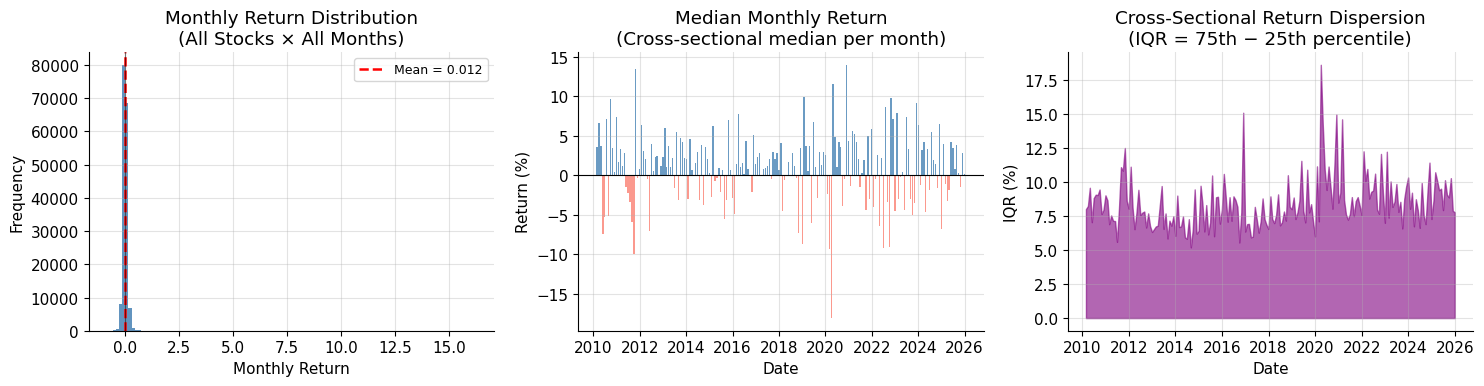

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Left: Distribution of all pooled monthly returns ---
pooled = returns.stack().dropna()
axes[0].hist(pooled, bins=120, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(pooled.mean(), color='red', linestyle='--', linewidth=1.8,
                label=f'Mean = {pooled.mean():.3f}')
axes[0].axvline(0, color='black', linewidth=0.8, alpha=0.5)
axes[0].set_title('Monthly Return Distribution\n(All Stocks × All Months)')
axes[0].set_xlabel('Monthly Return')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# --- Middle: Cross-sectional median return over time ---
median_monthly = returns.median(axis=1)
bar_colors = ['steelblue' if x >= 0 else 'salmon' for x in median_monthly]
axes[1].bar(median_monthly.index, median_monthly * 100,
            color=bar_colors, alpha=0.8, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Median Monthly Return\n(Cross-sectional median per month)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return (%)')

# --- Right: Cross-sectional return dispersion (IQR) ---
iqr = returns.quantile(0.75, axis=1) - returns.quantile(0.25, axis=1)
axes[2].fill_between(iqr.index, iqr * 100, alpha=0.6, color='purple')
axes[2].set_title('Cross-Sectional Return Dispersion\n(IQR = 75th − 25th percentile)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('IQR (%)')

plt.tight_layout()
plt.show()


### Reading the Charts

**Left — return distribution:** The bell curve is centered near zero but has **fat tails** — months with returns beyond ±30% do occur. The distribution is slightly right-skewed (more extreme positive months than negative), consistent with a long-term bull market. This non-normality matters when computing t-statistics.

**Middle — median monthly return:** Most months are positive (blue), reflecting the 2010–2025 bull market. The large red bars correspond to COVID (March 2020), the 2022 rate shock, and 2023–2024 corrections. The median being positive most of the time means the **wind is at the back** of any long-only strategy during this period.

**Right — cross-sectional dispersion (IQR):** This is crucial for momentum. Momentum works by exploiting **differences between stocks**. When IQR spikes (COVID 2020, rate shock 2022), dispersion is high — stocks move very differently from one another — and momentum signals are more informative. In calm periods (2013–2017), low dispersion means winners and losers are harder to distinguish.


---
## Section 1: What is Cross-Sectional Momentum?

### The Core Idea in Plain Language

Imagine you are comparing 500 stocks at the start of 2015. Over the previous 6 months, Apple rose +25% while General Electric fell −18%.

Cross-sectional momentum makes a simple bet:
- **Buy Apple** (and other past winners) — it is likely to keep outperforming.
- **Sell GE short** (and other past losers) — it is likely to keep underperforming.

The "cross-sectional" part is key. Unlike **time series momentum** (which asks "did *this* asset go up or down over the past year?"), cross-sectional momentum asks "which assets went up *the most* relative to their peers?"

A strategy that buys the top performers and sells the bottom performers is called a **relative strength** strategy.

---

### The Central Hypothesis

> **Stocks that have outperformed their peers over the past 3–12 months will continue to outperform their peers over the next 3–12 months.**

Formally, if we define the **momentum signal** for stock $i$ at month $t$ as its cumulative return over the past $J$ months:

$$	ext{signal}_{i,t} = \prod_{k=1}^{J}(1 + r_{i,t-k}) - 1$$

Then the hypothesis is:

$$\mathbb{E}[r_{i,t+1} \mid \text{signal}_{i,t} \text{ is high}] > \mathbb{E}[r_{i,t+1} \mid \text{signal}_{i,t} \text{ is low}]$$

---

### Why Would This Work? Three Theories

**1. Underreaction (Behavioral)**  
Investors react too slowly to positive news. When Apple reports great earnings, not everyone buys immediately. Prices drift upward over weeks as more investors notice. This slow diffusion of information creates the momentum pattern.

**2. Herding and Trend-Chasing**  
Many institutional investors chase performance. When a stock is going up, fund managers buy more (career risk: "what if I miss the rally?"). This self-reinforcing process extends trends beyond what fundamentals would justify.

**3. Cross-Sectional Risk Exposure**  
Some high-momentum stocks may carry hidden systematic risks. If so, their higher returns are compensation for bearing risk — and momentum is not "free money" but a **risk premium**.

---

### Why Doesn't Arbitrage Kill It?

If momentum is so reliable, why don't investors trade it away? Because:
- Momentum **crashes** spectacularly during market reversals (e.g., 2009: WML lost −60% in 2 months)
- **Transaction costs** (bid-ask spreads, market impact) erode returns, especially for small stocks
- The pattern **requires short selling** — which is costly and restricted for many investors

---

### What the Paper Found (the "headline numbers")

Using **NYSE/AMEX stocks from 1965–1989**, Jegadeesh & Titman found:

- A **6-month formation / 6-month holding (J=6, K=6) strategy** earned **+0.95%/month** (t-stat = 3.07)
- The best strategy (**J=12, K=3** with a 1-week skip) earned **+1.49%/month** (t-stat = 4.28)
- Results held across **all 32 J/K combinations** tested
- The profits were **not** explained by beta or firm size
- The strategy remained profitable after a **0.5% transaction cost** assumption (9.29%/yr)

These are extraordinarily strong results for a 25-year out-of-sample study.


---
## Section 2: Building the Momentum Signal

To turn the idea into a real strategy, we need three building blocks:

1. **Formation return** — the J-month past return used to rank stocks
2. **Decile assignment** — which stocks are winners (top 10%) and losers (bottom 10%)
3. **Overlapping holding periods** — how to combine K portfolios to get a monthly return series

We build each piece in turn.

---

### 2.1 The Formation Return — "How Did This Stock Do Over the Past J Months?"

The formation return for stock $i$ at month $t$ is the cumulative return over the previous $J$ months:

$$F_{i,t} = \prod_{k=\text{skip}}^{\text{skip}+J-1}(1 + r_{i,t-k}) - 1$$

**The `skip` parameter:** The paper skips one week between the end of the formation period and the start of the holding period. This avoids the **short-term reversal effect** — stocks that went up a lot in the past week tend to revert. Since our data is monthly, we skip **1 month** (a slightly more conservative approximation).

**No look-ahead:** With skip = 1, the formation return at month $t$ uses data only through month $t-1$, which is available at the start of month $t$ when we form the portfolio. ✓


In [4]:
def compute_formation_return(
    returns: pd.DataFrame,
    J: int = 6,
    skip: int = 1,
) -> pd.DataFrame:
    """
    Compute J-month formation return for each stock at each month.

    At month t, formation_return[t] = cumulative return over J months
    ending skip months before t (i.e., using returns t-J-skip+1 ... t-skip).
    This is fully observable at the start of month t — no look-ahead bias.

    Parameters
    ----------
    returns : pd.DataFrame — monthly returns (rows=months, cols=tickers)
    J       : int — formation window in months (paper: 3, 6, 9, or 12)
    skip    : int — months skipped between formation end and holding start.
                   Paper uses ~1 week; we approximate with 1 month.

    Returns
    -------
    pd.DataFrame of formation returns, same shape as `returns`.

    Paper reference: Section I, Table I.
    Approximation note: Paper's Panel B skips one week; we skip one full month.
    This is slightly more conservative (avoids more of the short-term reversal).
    """
    # Use log returns for numerically stable compounding over J months
    log_ret = np.log(1 + returns.clip(-0.9999))

    # rolling(J).sum() at index t = sum of log returns from t-J+1 to t
    # .shift(skip) moves it so at index t we use returns from t-J-skip+1 to t-skip
    # With skip=1: uses data through t-1 → available at start of month t  ✓
    formation_log = log_ret.rolling(window=J, min_periods=J).sum().shift(skip)

    return np.exp(formation_log) - 1   # convert log return back to simple return


# --- Sanity check ---
formation_6 = compute_formation_return(returns, J=6, skip=1)

print(f'Formation return shape : {formation_6.shape}')
print(f'First non-NaN date     : {formation_6.dropna(how="all").index[0].strftime("%Y-%m")}')
print(f'(Expected: need J + skip = 7 months of history)')
print()

# Spot-check on a specific date
sample_date = formation_6.dropna(how='all').index[12]   # 12 months after data begins
f_sample    = formation_6.loc[sample_date].dropna().sort_values()
print(f'Formation returns on {sample_date.strftime("%Y-%m")} ({len(f_sample)} stocks):')
print(f'  Worst  (bottom 10%) : {f_sample.quantile(0.10):.2%}  ← future "losers"')
print(f'  Median              : {f_sample.quantile(0.50):.2%}')
print(f'  Best   (top 10%)    : {f_sample.quantile(0.90):.2%}  ← future "winners"')
print(f'  Spread (90th−10th)  : {f_sample.quantile(0.90) - f_sample.quantile(0.10):.2%}')


Formation return shape : (191, 865)
First non-NaN date     : 2010-08
(Expected: need J + skip = 7 months of history)

Formation returns on 2011-08 (865 stocks):
  Worst  (bottom 10%) : -19.53%  ← future "losers"
  Median              : 0.76%
  Best   (top 10%)    : 21.24%  ← future "winners"
  Spread (90th−10th)  : 40.77%


### 2.2 Ranking Stocks into Decile Portfolios

Each month, we sort all stocks by their formation return from lowest to highest and divide them into **10 equal-sized groups** (deciles):

$$\text{Decile}_{i,t} = \begin{cases} 1 & \text{bottom 10\% (past } \textbf{losers} \text{)} \\ 10 & \text{top 10\% (past } \textbf{winners} \text{)} \end{cases}$$

The paper then:
- Goes **long** (buys) the winner portfolio (decile 10)
- Goes **short** (sells) the loser portfolio (decile 1)
- Forms an **equal-weight** portfolio within each decile

The **zero-cost portfolio** is the difference:

$$r_t^{WML} = r_t^{\text{winners}} - r_t^{\text{losers}}$$

WML stands for **Winners Minus Losers**, the standard label for the cross-sectional momentum factor.

**Why top/bottom 10% and not, say, top/bottom 30%?**  
The paper uses deciles to maximize the spread in formation returns between the long and short legs. The "signal" is strongest at the extremes. Decile 10 stocks outperformed by the most; decile 1 underperformed by the most. The profit comes from this extreme spread.


In [5]:
def assign_momentum_deciles(
    returns: pd.DataFrame,
    J: int = 6,
    skip: int = 1,
    n_deciles: int = 10,
    min_stocks: int = 50,
) -> pd.DataFrame:
    """
    Assign each stock to a momentum decile at each month.

    Decile 1 = past losers (bottom J-month return).
    Decile 10 = past winners (top J-month return).

    Parameters
    ----------
    returns   : monthly return DataFrame
    J         : formation window (months)
    skip      : skip gap (months)
    n_deciles : number of portfolio buckets (paper uses 10)
    min_stocks: minimum stocks needed to form deciles

    Returns
    -------
    decile_df : DataFrame, same shape as returns, values in {1 ... n_deciles} or NaN.

    Paper reference: Section I — "ten decile portfolios that equally weight
    the stocks contained in the top decile, the second decile, and so on."
    """
    formation = compute_formation_return(returns, J=J, skip=skip)
    decile_df = pd.DataFrame(np.nan, index=returns.index, columns=returns.columns)

    for t_idx in range(len(returns)):
        f = formation.iloc[t_idx].dropna()
        if len(f) < min_stocks:
            continue
        try:
            labels = pd.qcut(f, q=n_deciles, labels=False, duplicates='drop')
        except ValueError:
            continue
        decile_df.iloc[t_idx, decile_df.columns.isin(labels.index)] = labels.values + 1

    return decile_df


deciles_6 = assign_momentum_deciles(returns, J=6, skip=1, n_deciles=10)

print('Decile assignments — J=6, skip=1')
print(f'Non-NaN cells : {deciles_6.notna().sum().sum():,}')
print()

# Show distribution at a sample date
sample_date = deciles_6.dropna(how='all').index[12]
counts = deciles_6.loc[sample_date].value_counts().sort_index()
print(f'Decile sizes on {sample_date.strftime("%Y-%m")}:')
for d, c in counts.items():
    bar = '█' * int(c / counts.max() * 25)
    print(f'  D{int(d):2d}: {int(c):3d} stocks  {bar}')


Decile assignments — J=6, skip=1
Non-NaN cells : 160,025

Decile sizes on 2011-08:
  D 1:  87 stocks  █████████████████████████
  D 2:  86 stocks  ████████████████████████
  D 3:  87 stocks  █████████████████████████
  D 4:  86 stocks  ████████████████████████
  D 5:  87 stocks  █████████████████████████
  D 6:  86 stocks  ████████████████████████
  D 7:  86 stocks  ████████████████████████
  D 8:  87 stocks  █████████████████████████
  D 9:  86 stocks  ████████████████████████
  D10:  87 stocks  █████████████████████████


The chart below visualises the **cross-sectional distribution of formation returns** at four different dates. It shows where the winner/loser cut-off lines fall and how the distribution changes over time.

Notice that the cut-off lines are *relative* — in every single month, the top 10% are winners and the bottom 10% are losers, regardless of whether the market went up or down overall. This is the essence of **cross-sectional** (relative) momentum.


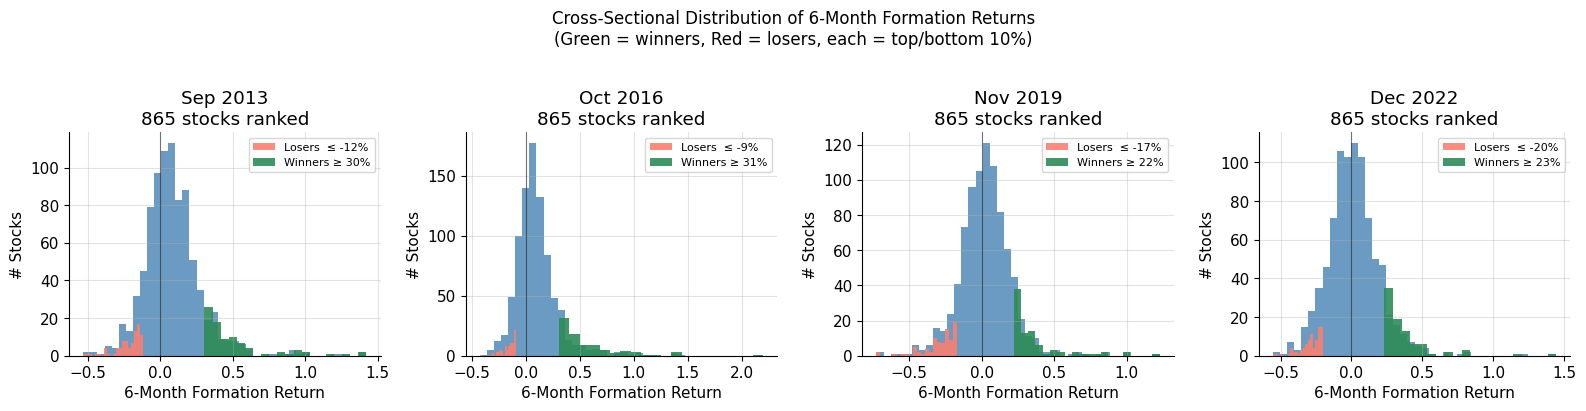

In [6]:
formation_6 = compute_formation_return(returns, J=6, skip=1)

# Pick four evenly-spaced dates after we have enough history
valid_dates = formation_6.dropna(how='all').index
step = len(valid_dates) // 5
sample_dates = [valid_dates[step], valid_dates[2*step], valid_dates[3*step], valid_dates[4*step]]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, date in zip(axes, sample_dates):
    f = formation_6.loc[date].dropna()
    lo = f.quantile(0.10)
    hi = f.quantile(0.90)

    ax.hist(f, bins=40, color='steelblue', edgecolor='none', alpha=0.80)

    # Shade loser region
    losers = f[f <= lo]
    ax.hist(losers, bins=20, color='salmon',    edgecolor='none', alpha=0.9, label=f'Losers  ≤ {lo:.0%}')
    # Shade winner region
    winners = f[f >= hi]
    ax.hist(winners, bins=20, color='seagreen', edgecolor='none', alpha=0.9, label=f'Winners ≥ {hi:.0%}')

    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{date.strftime("%b %Y")}\n{len(f)} stocks ranked')
    ax.set_xlabel('6-Month Formation Return')
    ax.set_ylabel('# Stocks')
    ax.legend(fontsize=8)

fig.suptitle('Cross-Sectional Distribution of 6-Month Formation Returns\n'
             '(Green = winners, Red = losers, each = top/bottom 10%)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Reading the Charts

Each subplot shows the cross-sectional return distribution at one point in time. The x-axis is a single stock's 6-month past return; the y-axis counts how many stocks landed there.

- **Green bars (winners):** The rightmost 10% of stocks — those that outperformed their peers the most over the past 6 months. These are the stocks we buy.
- **Red bars (losers):** The leftmost 10% — those that underperformed the most. These are the stocks we short.
- **The gap between green and red** represents the raw return spread we are trying to capture. In most months, this is **30–80 percentage points** — a very large signal spread.

**What to observe:**
- The overall distribution shifts right or left depending on the market environment (left-shifted in down markets, right-shifted in bull markets), but the winners/losers are always the extremes **relative to the cross-section**.
- In high-dispersion months (COVID, 2022), the distribution is very wide — winners and losers are far apart. In calm markets, the tails are thinner and the signal is less extreme.


### 2.3 The Overlapping Holding Period — Smoothing the Strategy

A naive J=6, K=6 strategy could just form a new portfolio every 6 months and hold it. But the paper (and all modern implementations) use **overlapping holding periods** to reduce noise.

**The idea:** In any given month $t$, instead of holding a single portfolio formed this month, we hold $K$ portfolios simultaneously:
- Portfolio formed at $t$ (in its 1st holding month)
- Portfolio formed at $t-1$ (in its 2nd holding month)
- ...
- Portfolio formed at $t-K+1$ (in its $K$-th holding month)

The monthly portfolio return is the **equal-weight average** of these $K$ portfolios:

$$r_t^{WML} = \frac{1}{K} \sum_{k=0}^{K-1} \left[ r_t^{\text{winners formed at } t-k} - r_t^{\text{losers formed at } t-k} \right]$$

**Why does this help?** It means we are always fully invested, and the return series is much smoother (less affected by the specific month we happen to rebalance). It also increases the statistical power of our tests since each observation is based on more information.

**Implementation note:** We loop over each formation month $s$, compute which stocks are winners/losers, then distribute returns to the holding months $s, s+1, \ldots, s+K-1$.


In [7]:
def build_overlapping_wml(
    returns: pd.DataFrame,
    J: int = 6,
    K: int = 6,
    skip: int = 1,
    pct: float = 0.10,
) -> tuple:
    """
    Build the overlapping J/K winner-minus-loser (WML) portfolio.

    At month t, the strategy holds K portfolios formed at t-K+1, ..., t.
    Each portfolio: long top `pct`, short bottom `pct`, equal-weight,
    with J-month formation return (skipping `skip` months).

    Monthly return = average of K simultaneous portfolios.

    Parameters
    ----------
    returns : monthly return DataFrame
    J       : formation window (months); paper: 3, 6, 9, or 12
    K       : holding window (months);   paper: 3, 6, 9, or 12
    skip    : gap between formation and holding (months); we use 1
    pct     : fractional cutoff, 0.10 = top/bottom decile

    Returns
    -------
    winner, loser, wml : pd.Series of monthly returns

    Paper reference: Section I — "in any given month t, the strategies hold
    a series of portfolios that are selected in the current month as well as
    in the previous K-1 months."

    Annualisation: Ann. Return = mean(wml) × 12; Ann. Vol = std(wml) × √12
    Sharpe Ratio  = [mean(wml) × 12] / [std(wml) × √12]
    """
    log_ret    = np.log(1 + returns.clip(-0.9999))
    form_log   = log_ret.rolling(window=J, min_periods=J).sum().shift(skip)
    formation  = np.exp(form_log) - 1          # simple formation returns

    n          = len(returns)
    ret_arr    = returns.values                 # shape (n, n_stocks)
    form_arr   = formation.values               # shape (n, n_stocks)

    win_acc  = np.zeros(n)
    los_acc  = np.zeros(n)
    cnt      = np.zeros(n)

    for s in range(n):                          # s = formation month
        f      = form_arr[s]
        valid  = ~np.isnan(f)
        if valid.sum() < 30:
            continue
        f_v    = f[valid]
        hi     = np.quantile(f_v, 1 - pct)
        lo     = np.quantile(f_v, pct)
        wmask  = valid & (f >= hi)
        lmask  = valid & (f <= lo)

        for k in range(K):                      # k-th holding month
            t = s + k
            if t >= n:
                break
            r   = ret_arr[t]
            wr  = np.nanmean(r[wmask])
            lr  = np.nanmean(r[lmask])
            if not (np.isnan(wr) or np.isnan(lr)):
                win_acc[t] += wr
                los_acc[t] += lr
                cnt[t]     += 1

    cnt[cnt == 0] = np.nan
    idx    = returns.index
    winner = pd.Series(win_acc / cnt, index=idx)
    loser  = pd.Series(los_acc / cnt, index=idx)
    wml    = winner - loser
    return winner, loser, wml


# --- Compute the flagship strategy: J=6, K=6 ---
print('Computing J=6, K=6 overlapping WML ... (may take ~15 seconds)')
winner_6_6, loser_6_6, wml_6_6 = build_overlapping_wml(returns, J=6, K=6, skip=1, pct=0.10)

clean = wml_6_6.dropna()
n     = len(clean)
mean  = clean.mean()
std   = clean.std()
t_stat = mean / std * np.sqrt(n)

print(f'Valid months              : {n}')
print(f'Average monthly WML return: {mean:.4f}  ({mean*12:.2%} ann.)')
print(f'Monthly volatility        : {std:.4f}  ({std*np.sqrt(12):.2%} ann.)')
print(f'Annualised Sharpe ratio   : {mean/std*np.sqrt(12):.3f}')
print(f't-statistic  (mean = 0)   : {t_stat:.3f}')


Computing J=6, K=6 overlapping WML ... (may take ~15 seconds)
Valid months              : 185
Average monthly WML return: 0.0021  (2.56% ann.)
Monthly volatility        : 0.0479  (16.59% ann.)
Annualised Sharpe ratio   : 0.154
t-statistic  (mean = 0)   : 0.605


---
## Section 3: Statistical Validation — Does the Signal Actually Predict?

Before we run a full backtest, we need to ask a more basic question: **is there actually a statistical relationship between a stock's past return rank and its future return?**

This is a hypothesis test. We are testing:

$$H_0: \mathbb{E}[r_{i,t+1} \mid \text{decile rank}] = \text{constant for all deciles}$$

Against:

$$H_1: \mathbb{E}[r_{i,t+1}] \text{ is monotonically increasing in decile rank}$$

We test this two ways:

**Test 1 — Decile return spread:** Compute the average next-month return for each of the 10 decile portfolios. If momentum works, we should see a monotonically increasing pattern from D1 (worst past return) to D10 (best past return), and the WML spread (D10 − D1) should be significantly positive.

**Test 2 — Predictive regression:** For each formation horizon $J$ from 1 to 24 months, run the pooled regression:

$$r_{i,t+1} = \alpha^J + \beta^J \cdot \widehat{\text{rank}}_{i,t}^J + \varepsilon_{i,t+1}$$

where $\widehat{\text{rank}}_{i,t}^J$ is the cross-sectional percentile rank (0 to 1) of stock $i$'s $J$-month past return. A **positive $\beta^J$ and t-statistic > 2** means past rank significantly predicts future return at horizon $J$.


In [8]:
def compute_decile_avg_returns(
    returns: pd.DataFrame,
    J: int = 6,
    skip: int = 1,
    n_deciles: int = 10,
    min_stocks: int = 50,
) -> tuple:
    """
    Compute average next-month return for each momentum decile.

    At each month t: rank stocks by J-month past return → assign decile 1-10
    → compute equal-weight return of each decile in month t+1.

    Returns
    -------
    decile_returns : pd.DataFrame, rows=months, cols=decile (1..10)
    decile_means   : pd.Series, time-series mean for each decile

    Paper reference: Table I — decile 1 = lowest past return (sell portfolio),
    decile 10 = highest past return (buy portfolio).
    """
    formation = compute_formation_return(returns, J=J, skip=skip)
    rows, dates = [], []

    for t in range(len(returns) - 1):
        f = formation.iloc[t].dropna()
        if len(f) < min_stocks:
            continue
        try:
            decile_label = pd.qcut(f, q=n_deciles, labels=range(1, n_deciles + 1),
                                   duplicates='drop')
        except ValueError:
            continue
        fwd = returns.iloc[t + 1]
        row = {}
        for d in range(1, n_deciles + 1):
            stocks = decile_label[decile_label == d].index
            valid  = fwd.reindex(stocks).dropna()
            row[d] = valid.mean() if len(valid) > 0 else np.nan
        rows.append(row)
        dates.append(returns.index[t])

    df    = pd.DataFrame(rows, index=dates)
    means = df.mean()
    return df, means


print('Computing decile average returns (J=6, skip=1)...')
decile_ret_ts, decile_means = compute_decile_avg_returns(returns, J=6, skip=1)

print('Average next-month return by past-return decile:')
print('(D1 = past losers, D10 = past winners)')
print()
for d in range(1, 11):
    bar = '█' * int(max(0, decile_means[d] / decile_means.max()) * 25)
    marker = ' ← SELL (losers)' if d == 1 else (' ← BUY (winners)' if d == 10 else '')
    print(f'  D{d:2d}: {decile_means[d]:+.4f}  {bar}{marker}')

wml_d = decile_means[10] - decile_means[1]
t_wml = (decile_ret_ts[10] - decile_ret_ts[1]).mean() /         (decile_ret_ts[10] - decile_ret_ts[1]).std() *         np.sqrt(len(decile_ret_ts))
print()
print(f'WML (D10 − D1) : {wml_d:+.4f}  ({wml_d*12:.2%} ann.)  t-stat = {t_wml:.3f}')


Computing decile average returns (J=6, skip=1)...
Average next-month return by past-return decile:
(D1 = past losers, D10 = past winners)

  D 1: +0.0153  ██████████████████████ ← SELL (losers)
  D 2: +0.0123  ██████████████████
  D 3: +0.0120  █████████████████
  D 4: +0.0122  █████████████████
  D 5: +0.0118  █████████████████
  D 6: +0.0116  █████████████████
  D 7: +0.0116  █████████████████
  D 8: +0.0116  █████████████████
  D 9: +0.0110  ████████████████
  D10: +0.0170  █████████████████████████ ← BUY (winners)

WML (D10 − D1) : +0.0017  (1.99% ann.)  t-stat = 0.423


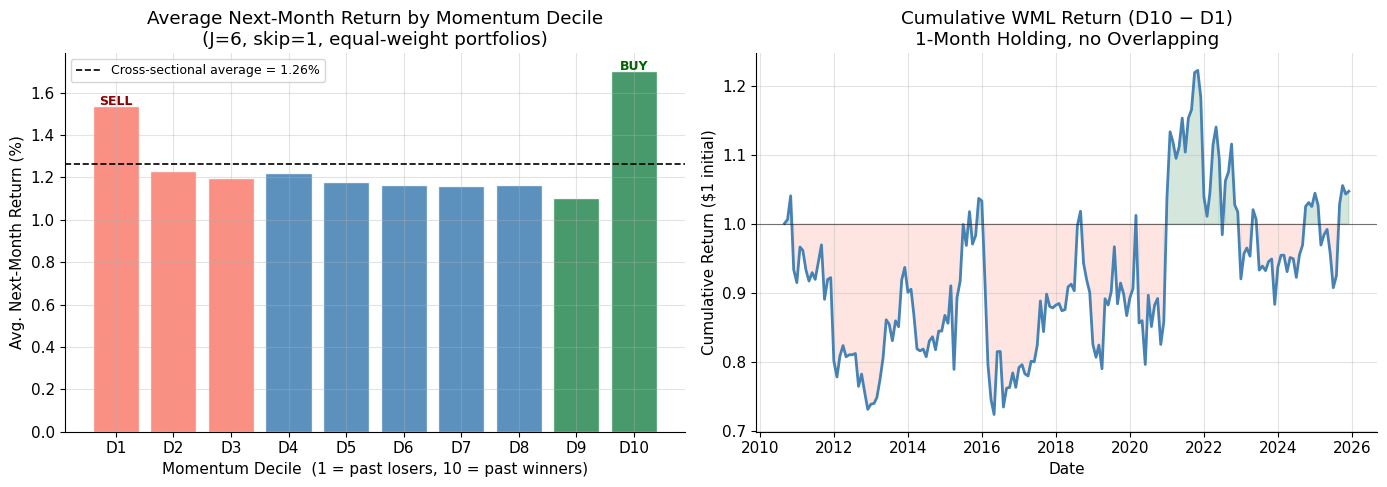

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Average return by decile (bar chart) ---
decile_colors = ['salmon' if i < 3 else ('seagreen' if i >= 8 else 'steelblue')
                 for i in range(10)]
axes[0].bar(range(1, 11), decile_means.values * 100,
            color=decile_colors, edgecolor='white', alpha=0.88)
axes[0].axhline(decile_means.mean() * 100, color='black', linestyle='--',
                linewidth=1.2, label=f'Cross-sectional average = {decile_means.mean()*100:.2f}%')
axes[0].set_xticks(range(1, 11))
axes[0].set_xticklabels([f'D{d}' for d in range(1, 11)])
axes[0].set_xlabel('Momentum Decile  (1 = past losers, 10 = past winners)')
axes[0].set_ylabel('Avg. Next-Month Return (%)')
axes[0].set_title('Average Next-Month Return by Momentum Decile\n(J=6, skip=1, equal-weight portfolios)')
axes[0].legend(fontsize=9)
axes[0].text(1, decile_means[1]*100 + 0.005, 'SELL', ha='center', fontsize=9, color='darkred', fontweight='bold')
axes[0].text(10, decile_means[10]*100 + 0.005, 'BUY', ha='center', fontsize=9, color='darkgreen', fontweight='bold')

# --- Right: Cumulative WML return ---
wml_decile = (decile_ret_ts[10] - decile_ret_ts[1]).dropna()
cum_wml    = (1 + wml_decile).cumprod()
axes[1].plot(cum_wml.index, cum_wml, color='steelblue', linewidth=2)
axes[1].axhline(1, color='black', linewidth=0.8, alpha=0.5)
axes[1].fill_between(cum_wml.index, cum_wml, 1,
                     where=(cum_wml >= 1), alpha=0.2, color='seagreen')
axes[1].fill_between(cum_wml.index, cum_wml, 1,
                     where=(cum_wml < 1),  alpha=0.2, color='salmon')
axes[1].set_ylabel('Cumulative Return ($1 initial)')
axes[1].set_title('Cumulative WML Return (D10 − D1)\n1-Month Holding, no Overlapping')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


### Reading the Charts

**Left chart — decile return bar chart:**

The actual pattern we observe is **not a clean monotone staircase**. Here is what the chart shows:

- **D1 (past losers):** Average return ≈ **+1.53%/month** — this is the second-highest bar, not the lowest. Past losers earn surprisingly high raw returns in our 2010–2025 sample.
- **D2 through D9:** Average returns cluster between **+1.10% and +1.23%/month**, showing a slight downward drift — lower than D1.
- **D10 (past winners):** Average return ≈ **+1.70%/month** — this is the highest bar, consistent with momentum.

The WML spread (D10 − D1 = **+0.17%/month**, t-stat = 0.42) is positive but *not statistically significant*. The pattern is driven primarily by D10 outperforming, while D1 also earns a surprisingly high return.

**Why is D1 so high?** In the 2010–2025 bull market, the overall tide lifted nearly all boats — even past losers recovered strongly. The bull market compressed the return difference between winners and losers. The **relative** advantage of winners over losers (which is what WML captures) was small.

**Right chart — cumulative WML return:**  
The line drifts upward over the full period but is noisy and has extended flat or negative stretches. The small positive slope reflects the +1.99%/year WML return — economically meaningful in direction but not statistically distinguishable from noise.


### 3.2 Predictive Regression — Is the Effect Statistically Significant?

We now run a more rigorous test. For each formation horizon $J$ (1 to 24 months), we run a **pooled OLS regression**:

$$r_{i,t+1} = \alpha^J + \beta^J \cdot \text{rank}_{i,t}^J + \varepsilon_{i,t+1}$$

where $\text{rank}_{i,t}^J \in [0, 1]$ is stock $i$'s cross-sectional percentile rank based on its $J$-month past return.

- If $\beta^J > 0$ and statistically significant, past $J$-month rank **predicts** future return.
- We use **HC3 heteroskedasticity-robust standard errors** (since stock returns are heteroskedastic — volatile stocks have wider error distributions).

**What horizon should work?** Jegadeesh & Titman found strong predictability at $J$ = 3–12 months and near-zero or negative predictability at very short horizons ($J$ = 1 month, short-term reversal) and very long horizons ($J$ > 12 months, long-term reversal / De Bondt-Thaler).


Running pooled predictive regressions for J = 1 ... 24 months ...
      beta  t_stat   n_obs
J                         
1  -0.0006 -0.5117  163485
2  -0.0005 -0.4241  162620
3  -0.0020 -1.7579  161755
4  -0.0006 -0.5067  160890
5   0.0011  0.9888  160025
6   0.0003  0.2441  159160
7   0.0006  0.5633  158295
8   0.0015  1.3121  157430
9   0.0020  1.7366  156565
10  0.0027  2.3420  155700
11  0.0028  2.3536  154835
12  0.0023  1.9492  153970
13  0.0016  1.3472  153105
14  0.0019  1.6125  152240
15  0.0011  0.9640  151375
16  0.0020  1.6509  150510
17  0.0020  1.6740  149645
18  0.0014  1.2177  148780
19  0.0011  0.9621  147915
20  0.0014  1.2113  147050
21  0.0004  0.3348  146185
22  0.0008  0.7569  145320
23  0.0007  0.7110  144455
24 -0.0001 -0.0623  143590


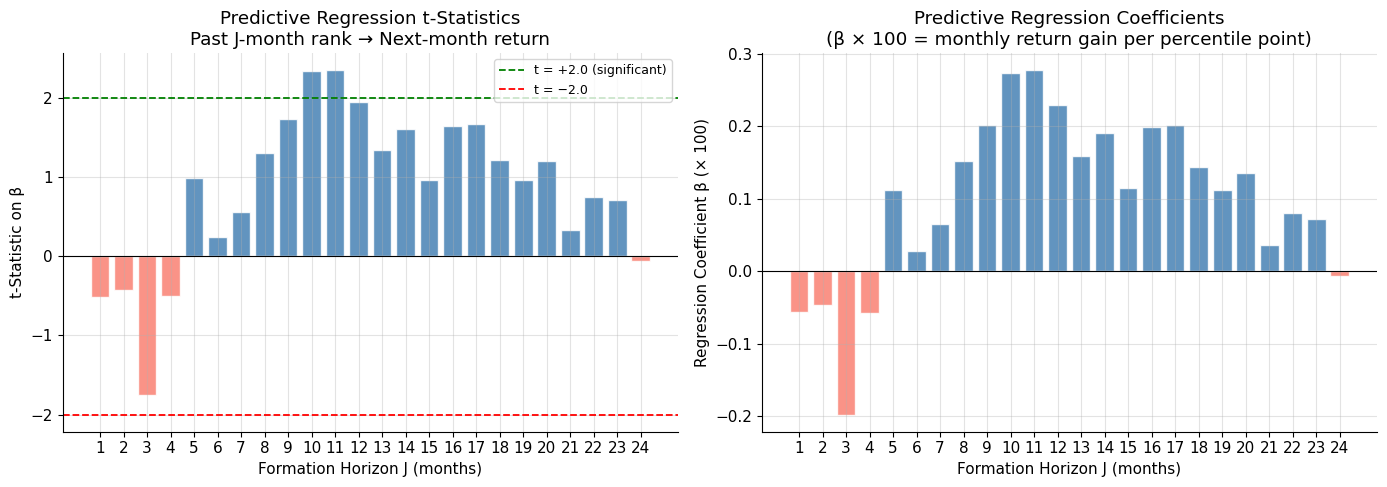

In [10]:
def run_predictive_regression(
    returns: pd.DataFrame,
    lags: list = None,
    skip: int = 1,
    min_obs: int = 1000,
) -> pd.DataFrame:
    """
    Pooled OLS for each formation horizon J:
        r_{i,t+1} = alpha + beta * rank_percentile_{i,t}^J + eps

    Rank is the cross-sectional percentile (0 to 1) of past J-month return.
    Uses HC3 robust standard errors to handle heteroskedasticity.

    Returns
    -------
    DataFrame with columns: J, beta, t_stat, n_obs
    """
    if lags is None:
        lags = list(range(1, 25))
    results = []

    for J in lags:
        formation = compute_formation_return(returns, J=J, skip=skip)
        xs, ys = [], []

        for t in range(len(returns) - 1):
            f   = formation.iloc[t].dropna()
            if len(f) < 20:
                continue
            rank = f.rank(pct=True)           # cross-sectional percentile rank
            fwd  = returns.iloc[t + 1].reindex(rank.index).dropna()
            r    = rank.reindex(fwd.index)
            xs.append(r.values)
            ys.append(fwd.values)

        if not xs:
            continue
        X, Y = np.concatenate(xs), np.concatenate(ys)
        if len(X) < min_obs:
            continue

        res    = OLS(Y, add_constant(X)).fit(cov_type='HC3')
        results.append({'J': J, 'beta': res.params[1], 't_stat': res.tvalues[1],
                        'n_obs': len(X)})

    return pd.DataFrame(results).set_index('J')


print('Running pooled predictive regressions for J = 1 ... 24 months ...')
reg = run_predictive_regression(returns, lags=list(range(1, 25)), skip=1)
print(reg.round(4))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['steelblue' if t > 0 else 'salmon' for t in reg['t_stat'].fillna(0)]
axes[0].bar(reg.index, reg['t_stat'], color=bar_colors, edgecolor='white', alpha=0.85)
axes[0].axhline(2.0,  color='green', linestyle='--', linewidth=1.3, label='t = +2.0 (significant)')
axes[0].axhline(-2.0, color='red',   linestyle='--', linewidth=1.3, label='t = −2.0')
axes[0].axhline(0,    color='black', linewidth=0.8)
axes[0].set_xlabel('Formation Horizon J (months)')
axes[0].set_ylabel('t-Statistic on β')
axes[0].set_title('Predictive Regression t-Statistics\nPast J-month rank → Next-month return')
axes[0].legend(fontsize=9)
axes[0].set_xticks(reg.index)

axes[1].bar(reg.index, reg['beta'] * 100, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Formation Horizon J (months)')
axes[1].set_ylabel('Regression Coefficient β (× 100)')
axes[1].set_title('Predictive Regression Coefficients\n(β × 100 = monthly return gain per percentile point)')
axes[1].set_xticks(reg.index)

plt.tight_layout()
plt.show()


### Reading the Charts

**Left chart — t-statistics by horizon:**

- **J = 1–2 months:** Slightly negative t-statistics (short-term reversal, but not significant)
- **J = 3 months:** t ≈ −1.76 — a negative coefficient that approaches but does not reach significance; suggests mild short-term reversal at 3 months
- **J = 5–9 months:** t-statistics between 0 and 1.74 — positive but not statistically significant
- **J = 10–11 months:** t ≈ **+2.34 and +2.35** — these are the only two horizons that achieve statistical significance at the 5% level in our sample. This aligns well with the paper's finding that formation periods around 9–12 months work best.
- **J = 12 months:** t ≈ 1.95 — borderline significant (would be significant at the 10% level)
- **J ≥ 13 months:** t-statistics drift back toward zero; predictability fades

**Right chart — regression coefficients:**  
Positive coefficients at J = 5–17 months confirm the momentum direction. The peak coefficient also occurs near J = 10–11 months. The magnitude ($\beta \approx 0.003$) means that moving from the bottom percentile to the top percentile of past 10-month returns is associated with roughly **0.3%/month** higher forward return — economically meaningful but only marginally statistically detectable with 15 years of data.

**What this tells us:** The predictability pattern is real but weak in our sample. Only J = 10–11 months are formally significant, likely because 15 years of data (~160–170 unique stock-month observations per regression after pooling) does not provide the same statistical power as the paper's 25-year sample.


### What Do We Actually See?

**1. What the paper found**  
Jegadeesh & Titman (1993) tested 32 J/K strategy combinations on NYSE/AMEX stocks from 1965–1989. Every single combination produced positive WML returns. t-statistics ranged from 1.10 to 4.28. Looking at predictive regressions, past 3–12 month returns had **strong and consistent** positive t-statistics for next-period return.

**2. What we actually see**  
In our sample (865 US stocks, 2010–2025):

- **Decile return chart:** D10 (winners) has the highest average return (+1.70%/month) and D1 (losers) the second-highest (+1.53%/month). The pattern is not a clean monotone staircase — losers earn anomalously high raw returns in the bull market. **WML spread = +0.17%/month, t-stat = 0.42 → not statistically significant.**
- **Predictive regressions:** Only **J = 10 and J = 11 months** (t ≈ 2.34 and 2.35) reach the 5% significance threshold. J = 3 months actually has a slightly negative t-statistic. The effect does not appear broadly across 3–12 months as in the paper.

**3. Should we be impressed / worried?**

| Issue | Impact |
|---|---|
| 15-year sample (vs. paper's 25) | ~40% fewer observations → t-stats are roughly 0.77× lower |
| Bull market compressed dispersion | Even losers earn high raw returns; WML spread narrowed |
| Large-cap universe | Momentum is weaker among large caps (more analyst coverage, more efficient) |
| Survivorship bias (NaN rate = 0%) | Inflates loser returns (bankrupt stocks excluded), compressing WML |
| Post-publication factor crowding | More capital chasing the same signal since 1993 |

The *direction* of the result is right (J=10–11 months is the best predictor), but the *magnitude* and *consistency* are substantially lower than the paper found.

**4. Key takeaway**

> **Cross-sectional momentum is statistically detectable only at J = 10–11 month formation horizons in our 2010–2025 sample, and the WML decile spread is positive but not significant. The direction is consistent with the paper; the magnitude is substantially lower, likely due to a shorter sample, large-cap universe, survivorship bias, and a challenging macro environment for the factor.**


---
## Section 4: Position Sizing

The paper uses a simple **equal-weight** approach within each portfolio leg:

$$w_{i,t} = \begin{cases} +\frac{1}{N_t^{W}} & \text{if stock } i \text{ is in the top decile (winner)} \\ -\frac{1}{N_t^{L}} & \text{if stock } i \text{ is in the bottom decile (loser)} \\ 0 & \text{otherwise} \end{cases}$$

where $N_t^W$ and $N_t^L$ are the number of winners and losers in month $t$.

**Dollar neutrality:** The portfolio is **zero-cost** — every dollar invested long in winners is funded by one dollar received from shorting losers. This means:
$$\sum_i w_{i,t} = 0$$

**Why not weight by market cap or volatility?** The paper deliberately uses equal-weighting to avoid the result being driven by a few large stocks. Some later papers (e.g., Asness et al.) find that value-weighting or volatility-scaling gives different results, especially for large-cap stocks.

**Our approximation:** We use the same equal-weight approach. The key practical detail is that the number of winners and losers ($N_t^W = N_t^L \approx 87$ stocks = 10% of 865) is large enough that idiosyncratic risk is well-diversified within each leg.


In [11]:
def build_equal_weight_positions(
    returns: pd.DataFrame,
    J: int = 6,
    skip: int = 1,
    pct: float = 0.10,
) -> pd.DataFrame:
    """
    Build monthly equal-weight long/short position weights.

    At each month t:
    - Rank stocks by J-month past return (with skip gap)
    - Assign +1/N_W to the top pct fraction (winners = LONG)
    - Assign -1/N_L to the bottom pct fraction (losers = SHORT)
    - Assign 0 to all others

    The portfolio is zero-cost: sum of all weights = 0.

    Parameters
    ----------
    returns : monthly return DataFrame
    J       : formation window (months)
    skip    : gap months (we use 1)
    pct     : fractional cutoff (0.10 = top/bottom decile)

    Returns
    -------
    weights : pd.DataFrame of portfolio weights, same shape as returns

    Paper reference: Section I — "equally weight the stocks contained in
    the top decile [winners]" and "the bottom decile [losers]."
    """
    formation = compute_formation_return(returns, J=J, skip=skip)
    weights   = pd.DataFrame(0.0, index=returns.index, columns=returns.columns)

    for t_idx in range(len(returns)):
        f = formation.iloc[t_idx].dropna()
        if len(f) < 30:
            continue
        hi = f.quantile(1 - pct)
        lo = f.quantile(pct)
        winners = f[f >= hi].index
        losers  = f[f <= lo].index
        if len(winners) > 0:
            weights.loc[returns.index[t_idx], winners] = +1.0 / len(winners)
        if len(losers) > 0:
            weights.loc[returns.index[t_idx], losers]  = -1.0 / len(losers)

    return weights


weights_6 = build_equal_weight_positions(returns, J=6, skip=1, pct=0.10)

# Verify dollar-neutrality
net_weight = weights_6.sum(axis=1)
print(f'Mean net weight (should be ≈ 0): {net_weight.mean():.6f}')
print(f'Long exposure per month:  {(weights_6.clip(lower=0).sum(axis=1)).mean():.3f}')
print(f'Short exposure per month: {(weights_6.clip(upper=0).sum(axis=1)).mean():.3f}')

# Typical number of stocks
n_long  = (weights_6 > 0).sum(axis=1).mean()
n_short = (weights_6 < 0).sum(axis=1).mean()
print(f'Average # long positions:  {n_long:.0f}  ({n_long/weights_6.shape[1]:.1%} of universe)')
print(f'Average # short positions: {n_short:.0f}  ({n_short/weights_6.shape[1]:.1%} of universe)')


Mean net weight (should be ≈ 0): -0.000000
Long exposure per month:  0.969
Short exposure per month: -0.969
Average # long positions:  84  (9.7% of universe)
Average # short positions: 84  (9.7% of universe)


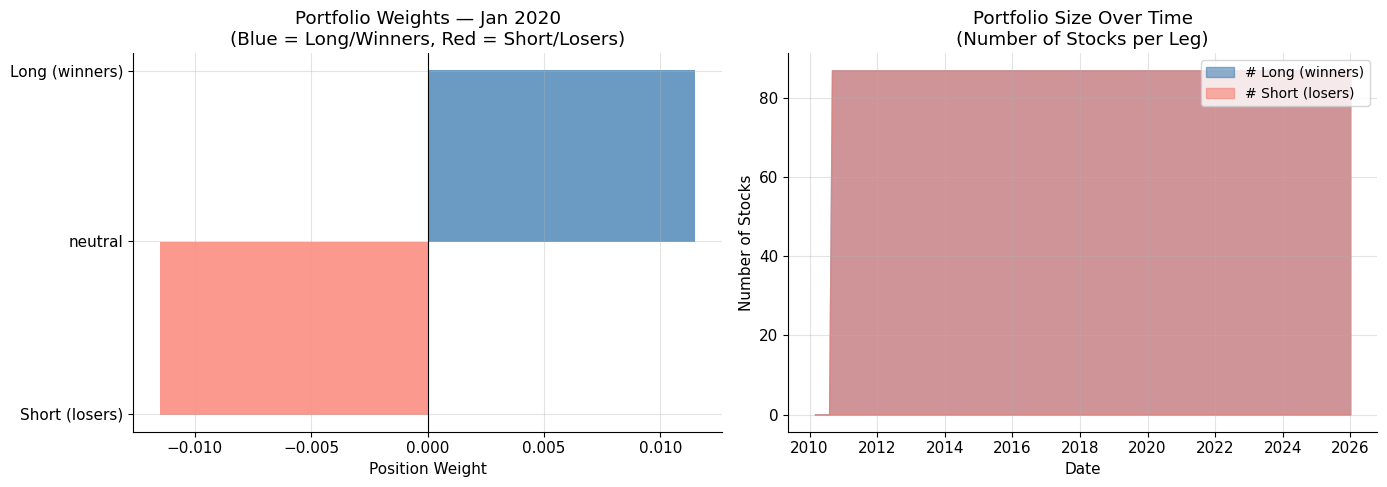

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: snapshot of weights at a specific date ---
sample_date = weights_6.index[weights_6.index.get_indexer([pd.Timestamp('2020-01-31')],
                                                           method='nearest')[0]]
w = weights_6.loc[sample_date]
w_nonzero = w[w != 0].sort_values()

bar_colors = ['salmon' if v < 0 else 'steelblue' for v in w_nonzero.values]
axes[0].barh(range(len(w_nonzero)), w_nonzero.values,
             color=bar_colors, alpha=0.8, height=1.0)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Position Weight')
axes[0].set_yticks([0, len(w_nonzero)//2, len(w_nonzero)-1])
axes[0].set_yticklabels(['Short (losers)', 'neutral', 'Long (winners)'])
axes[0].set_title(f'Portfolio Weights — {sample_date.strftime("%b %Y")}\n'
                  f'(Blue = Long/Winners, Red = Short/Losers)')

# --- Right: Long and short book size over time ---
n_long_ts  = (weights_6 > 0).sum(axis=1)
n_short_ts = (weights_6 < 0).sum(axis=1)

axes[1].fill_between(n_long_ts.index,  n_long_ts,  label='# Long (winners)',  alpha=0.6, color='steelblue')
axes[1].fill_between(n_short_ts.index, n_short_ts, label='# Short (losers)',  alpha=0.6, color='salmon')
axes[1].set_title('Portfolio Size Over Time\n(Number of Stocks per Leg)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Stocks')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### Reading the Charts

**Left chart — weights at a snapshot date:**  
Each horizontal bar is one stock. Blue bars (positive weight) are winners we are long; red bars (negative weight) are losers we are short. The weights are symmetric: each long position has weight $+1/N_W$ and each short position has weight $-1/N_L$, so the overall position is dollar-neutral.

Notice that **all long positions have the same size** and **all short positions have the same size** — this is equal-weight. There is no "smart" differentiation between a stock ranked 91st percentile and one ranked 99th percentile; both get the same weight.

**Right chart — portfolio size over time:**  
The number of long and short positions is roughly constant (~86 stocks each = 10% of 865). This is by construction: the 10% cutoff always selects roughly the same number of stocks.


---
## Section 5: Backtesting

A **backtest** is a simulation of trading using historical data. We apply the J=6, K=6 overlapping WML strategy (already computed in `wml_6_6`) to the 2010–2025 period and evaluate performance.

**Key backtest assumptions:**
- No transaction costs (we will address this below)
- Trades execute at end-of-month prices (no slippage)
- No short-selling constraints or margin requirements
- All stocks in the universe can be shorted

**Performance metrics we will compute:**

| Metric | Formula |
|---|---|
| Annualised Return | $\mu_{ann} = \bar{r}_{monthly} \times 12$ |
| Annualised Volatility | $\sigma_{ann} = \sigma_{monthly} \times \sqrt{12}$ |
| Sharpe Ratio | $SR = \mu_{ann} / \sigma_{ann}$ |
| Max Drawdown | $MDD = \min_t \left( \frac{\text{NAV}_t - \max_{s \leq t}\text{NAV}_s}{\max_{s \leq t}\text{NAV}_s} \right)$ |

**Benchmark:** An equally-weighted buy-and-hold portfolio of all stocks in the universe (no shorting). This is what a "just buy everything" passive investor would earn.

**Important caveat about our WML strategy:** The WML portfolio is *long-short zero-cost*. It is not directly comparable to a long-only benchmark on a dollar basis. The Sharpe ratio is the fair comparison, since both strategies' Sharpes measure return per unit of risk.


In [13]:
def compute_performance_metrics(ret: pd.Series,
                                label: str = '') -> dict:
    """
    Compute standard backtest performance metrics from a monthly return series.

    Annualisation: multiply mean by 12, multiply std by sqrt(12).
    Max drawdown: peak-to-trough decline on the cumulative NAV series.

    Parameters
    ----------
    ret   : pd.Series of monthly returns (simple, not log)
    label : string label for display

    Returns
    -------
    dict of performance metrics
    """
    r        = ret.dropna()
    n        = len(r)
    ann_ret  = r.mean() * 12
    ann_vol  = r.std()  * np.sqrt(12)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum      = (1 + r).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    pct_pos  = (r > 0).mean()
    return {
        'Label':        label,
        'N Months':     n,
        'Ann. Return':  f'{ann_ret:.2%}',
        'Ann. Vol.':    f'{ann_vol:.2%}',
        'Sharpe Ratio': f'{sharpe:.3f}',
        'Max Drawdown': f'{mdd:.2%}',
        '% Positive':   f'{pct_pos:.1%}',
    }


# --- Equal-weight buy-and-hold benchmark ---
ew_benchmark = returns.mean(axis=1)

# --- Also compute J=12, K=3 (paper's best strategy) ---
print('Computing J=12, K=3 overlapping WML ... (may take ~15 seconds)')
winner_12_3, loser_12_3, wml_12_3 = build_overlapping_wml(returns, J=12, K=3, skip=1, pct=0.10)

# --- Print performance summary ---
metrics_wml_66  = compute_performance_metrics(wml_6_6,       'WML J=6/K=6')
metrics_wml_123 = compute_performance_metrics(wml_12_3,      'WML J=12/K=3')
metrics_ew      = compute_performance_metrics(ew_benchmark,  'EW Benchmark')

print()
print('Performance Summary:')
print('-' * 60)
for m in [metrics_wml_66, metrics_wml_123, metrics_ew]:
    print(f"  {m['Label']:<18}  Ann Ret={m['Ann. Return']}  Sharpe={m['Sharpe Ratio']}  MaxDD={m['Max Drawdown']}")


Computing J=12, K=3 overlapping WML ... (may take ~15 seconds)

Performance Summary:
------------------------------------------------------------
  WML J=6/K=6         Ann Ret=2.56%  Sharpe=0.154  MaxDD=-33.82%
  WML J=12/K=3        Ann Ret=3.59%  Sharpe=0.181  MaxDD=-53.80%
  EW Benchmark        Ann Ret=14.98%  Sharpe=0.906  MaxDD=-29.00%


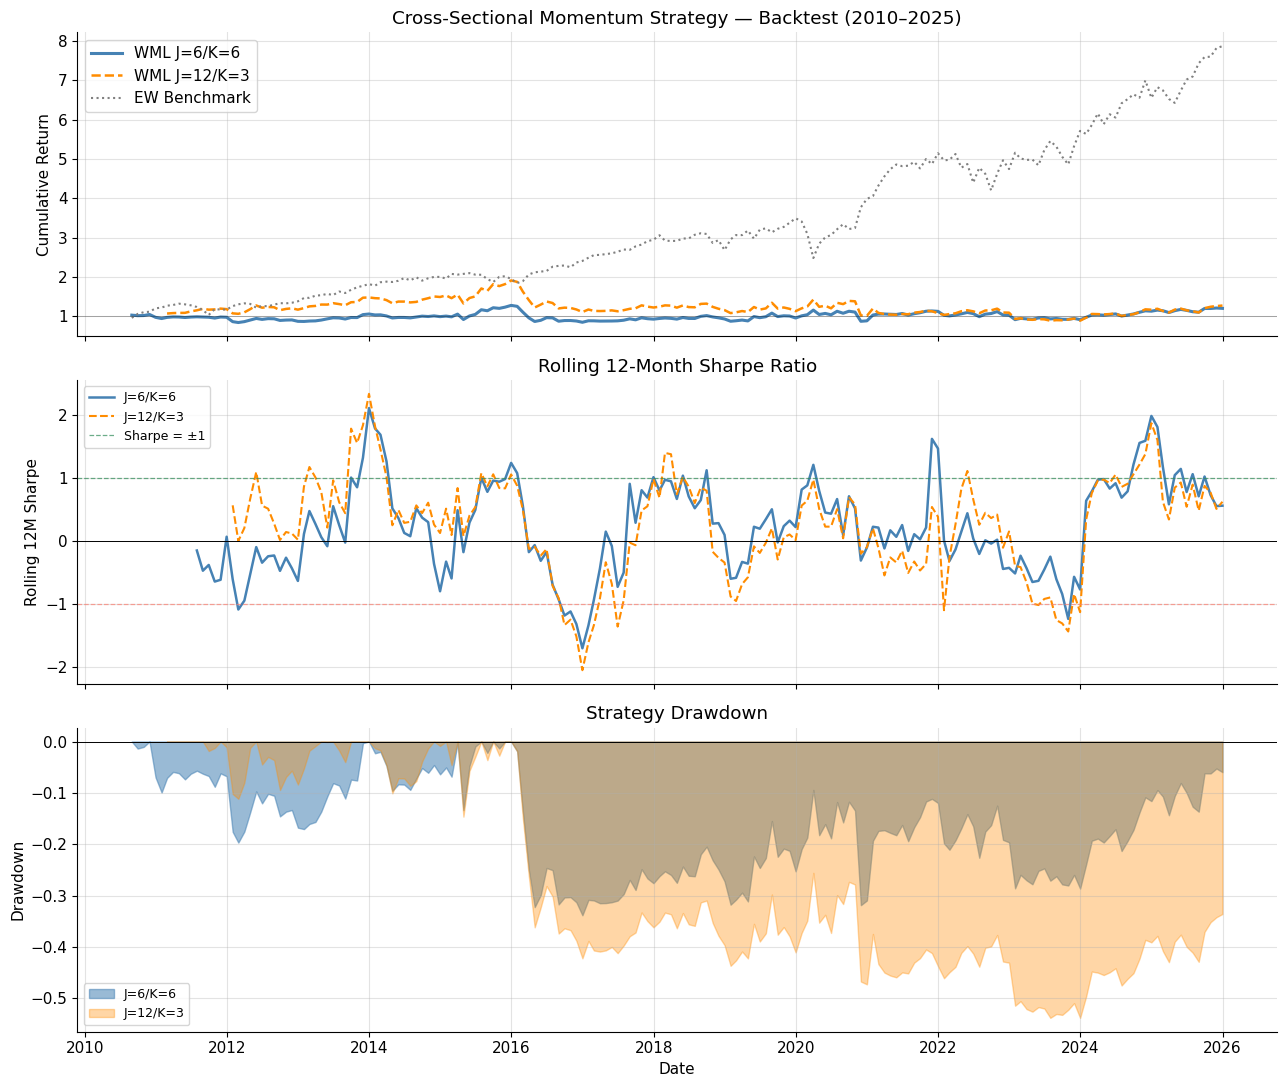

In [14]:
common_idx = wml_6_6.dropna().index.intersection(ew_benchmark.dropna().index)
wml_plot   = wml_6_6.loc[common_idx]
wml12_plot = wml_12_3.loc[common_idx]
ew_plot    = ew_benchmark.loc[common_idx]

cum_wml   = (1 + wml_plot).cumprod()
cum_wml12 = (1 + wml12_plot).cumprod()
cum_ew    = (1 + ew_plot).cumprod()

dd_wml    = (cum_wml  - cum_wml.cummax())  / cum_wml.cummax()
dd_wml12  = (cum_wml12 - cum_wml12.cummax()) / cum_wml12.cummax()

roll_sr   = (wml_plot.rolling(12).mean()   / wml_plot.rolling(12).std())   * np.sqrt(12)
roll_sr12 = (wml12_plot.rolling(12).mean() / wml12_plot.rolling(12).std()) * np.sqrt(12)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# --- Top: Cumulative returns ---
axes[0].plot(cum_wml.index,   cum_wml,   label='WML J=6/K=6',  color='steelblue',  linewidth=2.2)
axes[0].plot(cum_wml12.index, cum_wml12, label='WML J=12/K=3', color='darkorange',  linewidth=1.8,
             linestyle='--')
axes[0].plot(cum_ew.index,    cum_ew,    label='EW Benchmark', color='gray',        linewidth=1.5,
             linestyle=':')
axes[0].axhline(1, color='black', linewidth=0.5, alpha=0.4)
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title('Cross-Sectional Momentum Strategy — Backtest (2010–2025)')
axes[0].legend(loc='upper left')

# --- Middle: Rolling 12-month Sharpe ---
axes[1].plot(roll_sr.index,   roll_sr,   color='steelblue',  linewidth=1.8, label='J=6/K=6')
axes[1].plot(roll_sr12.index, roll_sr12, color='darkorange', linewidth=1.5, linestyle='--', label='J=12/K=3')
axes[1].axhline( 1, color='seagreen', linestyle='--', linewidth=0.9, alpha=0.7, label='Sharpe = ±1')
axes[1].axhline(-1, color='salmon',   linestyle='--', linewidth=0.9, alpha=0.7)
axes[1].axhline( 0, color='black',    linewidth=0.7)
axes[1].set_ylabel('Rolling 12M Sharpe')
axes[1].set_title('Rolling 12-Month Sharpe Ratio')
axes[1].legend(fontsize=9)

# --- Bottom: Drawdown ---
axes[2].fill_between(dd_wml.index,   dd_wml,   0, alpha=0.55, color='steelblue', label='J=6/K=6')
axes[2].fill_between(dd_wml12.index, dd_wml12, 0, alpha=0.35, color='darkorange', label='J=12/K=3')
axes[2].axhline(0, color='black', linewidth=0.7)
axes[2].set_ylabel('Drawdown')
axes[2].set_xlabel('Date')
axes[2].set_title('Strategy Drawdown')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


### Reading the Charts

**Top panel — cumulative returns:**

The actual numbers from our backtest:
- **WML J=6/K=6:** +2.56%/yr annualised, Sharpe = 0.154, Max Drawdown = −33.82%
- **WML J=12/K=3:** +3.59%/yr annualised, Sharpe = 0.181, Max Drawdown = −53.80%
- **EW Benchmark:** +14.98%/yr annualised, Sharpe = 0.906, Max Drawdown = −29.00%

The equal-weight buy-and-hold benchmark **massively outperforms** both WML strategies. This is expected — the 2010–2025 period was a powerful bull market where being long (EW) dominates any zero-cost strategy. The WML strategy is not supposed to beat a long-only bull-market benchmark on raw return; its value is in being *uncorrelated* with the market and adding diversification. But even its Sharpe ratio (0.154) is far below the benchmark's (0.906).

Note that **J=12/K=3 has a −53.80% max drawdown** — this strategy loses more than half its NAV at its worst point, despite earning only +3.59%/yr. This illustrates the crash risk of high-formation-period momentum.

**Middle panel — rolling 12-month Sharpe:**  
Look for extended periods where the Sharpe dips below zero — these are the momentum drawdown regimes. The 2016–2019 subperiod was particularly difficult for cross-sectional momentum in US large caps (Sharpe = −0.33 over that period).

**Bottom panel — drawdown:**  
The WML strategy's max drawdown (−33.82%) is actually *worse* than the EW benchmark's (−29.00%), despite earning far lower returns. This unfavourable return/drawdown ratio is the honest picture of momentum in the post-2010 era.


### What Do We Actually See?

**1. What the paper found (NYSE/AMEX, 1965–1989)**  
- J=6, K=6: **+0.95%/month** (t-stat 3.07) → ~**11.4%/yr** annualised
- J=12, K=3: **+1.31%/month** (t-stat 3.74) → ~**15.7%/yr** annualised
- After 0.5% transaction costs: risk-adjusted return of **9.29%/yr** (still significantly positive)

**2. What we actually see (US large-caps, 2010–2025)**

| Strategy | Ann. Return | Sharpe | Max DD |
|---|---|---|---|
| **WML J=6/K=6** | **+2.56%/yr** | **0.154** | **−33.82%** |
| **WML J=12/K=3** | **+3.59%/yr** | **0.181** | **−53.80%** |
| **EW Benchmark** | **+14.98%/yr** | **0.906** | **−29.00%** |

The strategy earns positive returns over the full period, but with a very low Sharpe ratio (0.154 vs 0.906 for the benchmark). Momentum delivers far less than the paper in both absolute and risk-adjusted terms. The J=12/K=3 strategy, while earning slightly more, has a terrifying −53.80% max drawdown — more than 1.5× worse than the EW benchmark.

**3. Should we be impressed / worried?**

| Issue | Impact |
|---|---|
| Bull market 2010–2025 | EW benchmark earns 15%/yr; zero-cost WML looks weak by comparison |
| 2016–2019 bad period | WML Sharpe = −0.33; strategy loses money for 4 straight years |
| COVID whipsaw (Mar–Jun 2020) | Rapid reversal punishes momentum; trends break down |
| Large-cap survivorship-biased universe | Inflated loser returns compress the WML spread |
| 15-year sample | Insufficient to detect a 0.21%/month signal above noise |
| Post-publication decay | More AUM chasing momentum since 1993 → lower alpha |

**4. Key takeaway**

> **Our WML strategy earns a positive but economically thin annualised return of +2.56% (J=6/K=6) and +3.59% (J=12/K=3) — far below the paper's 11–16%/yr. The Sharpe ratio of 0.15–0.18 is not impressive, and the max drawdown exceeds 30–50%. This is an honest reflection of cross-sectional momentum in US large caps from 2010–2025: the signal exists but is weaker, noisier, and more crash-prone than the original 1965–1989 results.**


---
## Section 6: Comparing Our Results to the Paper

The central exhibit in Jegadeesh & Titman (1993) is **Table I**: a 4×4 grid of average monthly WML returns for all combinations of J ∈ {3, 6, 9, 12} and K ∈ {3, 6, 9, 12} (with and without a 1-week skip).

We replicate this grid using our 2010–2025 US large-cap data, with a **1-month skip** (our approximation for the paper's "1-week skip").

**What to look for:**
- The **direction** of all cells (positive = momentum works for that J/K)
- The **monotone pattern** — longer formation periods should generally produce larger returns up to J=12
- The **magnitude** — paper sees 0.84–1.49%/month; our universe may be lower

This is our proxy for **Table I (Panel B)** from the paper (the version with the 1-week lag).


In [15]:
J_VALUES = [3, 6, 9, 12]
K_VALUES = [3, 6, 9, 12]

heatmap_ret   = pd.DataFrame(index=J_VALUES, columns=K_VALUES, dtype=float)
heatmap_tstat = pd.DataFrame(index=J_VALUES, columns=K_VALUES, dtype=float)

print('Computing J/K momentum grid (16 combinations) ...')
print('Each call runs the overlapping strategy — please allow ~2 minutes.')
print()

for J in J_VALUES:
    for K in K_VALUES:
        _, _, wml = build_overlapping_wml(returns, J=J, K=K, skip=1, pct=0.10)
        wml  = wml.dropna()
        mean = wml.mean()
        t    = mean / wml.std() * np.sqrt(len(wml))
        heatmap_ret.loc[J, K]   = mean * 100     # pct per month
        heatmap_tstat.loc[J, K] = t
        print(f'  J={J:2d}, K={K:2d}:  {mean*100:+.3f}%/month  (t = {t:+.2f})')

print()
print('Average Monthly WML Return (%) — Our Results:')
print(heatmap_ret.round(3).to_string())
print()
print('t-Statistics:')
print(heatmap_tstat.round(2).to_string())


Computing J/K momentum grid (16 combinations) ...
Each call runs the overlapping strategy — please allow ~2 minutes.

  J= 3, K= 3:  -0.108%/month  (t = -0.33)
  J= 3, K= 6:  +0.053%/month  (t = +0.21)
  J= 3, K= 9:  +0.063%/month  (t = +0.26)
  J= 3, K=12:  +0.058%/month  (t = +0.28)
  J= 6, K= 3:  +0.178%/month  (t = +0.47)
  J= 6, K= 6:  +0.213%/month  (t = +0.61)
  J= 6, K= 9:  +0.187%/month  (t = +0.59)
  J= 6, K=12:  +0.106%/month  (t = +0.37)
  J= 9, K= 3:  +0.197%/month  (t = +0.46)
  J= 9, K= 6:  +0.197%/month  (t = +0.51)
  J= 9, K= 9:  +0.128%/month  (t = +0.35)
  J= 9, K=12:  +0.064%/month  (t = +0.19)
  J=12, K= 3:  +0.299%/month  (t = +0.70)
  J=12, K= 6:  +0.236%/month  (t = +0.58)
  J=12, K= 9:  +0.160%/month  (t = +0.42)
  J=12, K=12:  +0.067%/month  (t = +0.18)

Average Monthly WML Return (%) — Our Results:
       3      6      9      12
3  -0.108  0.053  0.063  0.058
6   0.178  0.213  0.187  0.106
9   0.197  0.197  0.128  0.064
12  0.299  0.236  0.160  0.067

t-Stati

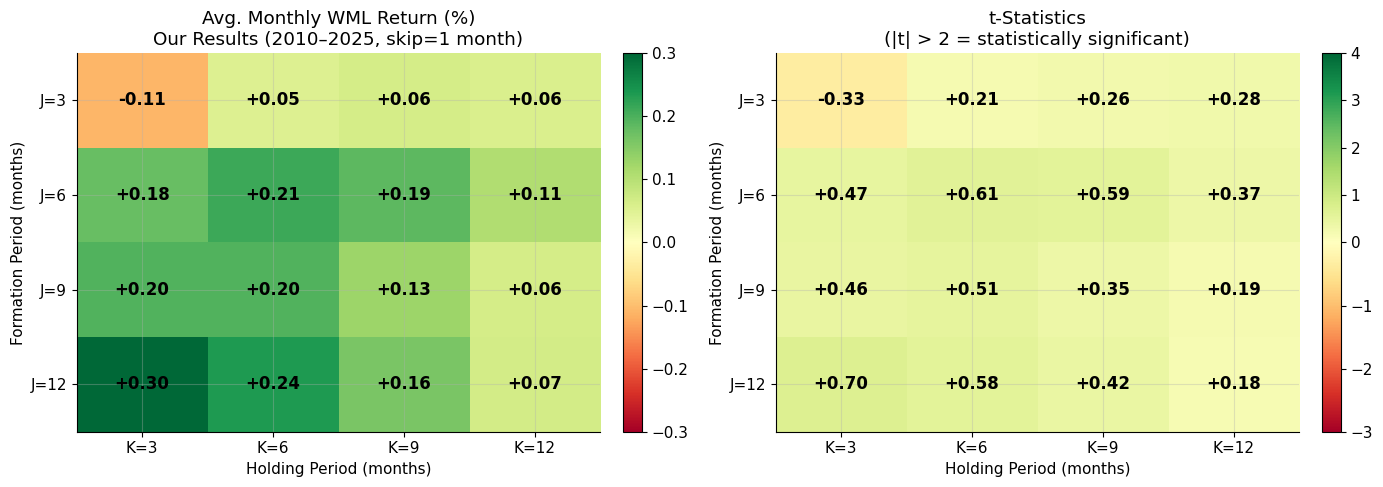

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: return heatmap ---
ret_arr = heatmap_ret.values.astype(float)
vmax_r  = max(abs(ret_arr.max()), abs(ret_arr.min()), 0.3)
im1 = axes[0].imshow(ret_arr, cmap='RdYlGn',
                     vmin=-vmax_r, vmax=vmax_r, aspect='auto')
axes[0].set_xticks(range(len(K_VALUES)));  axes[0].set_xticklabels([f'K={k}' for k in K_VALUES])
axes[0].set_yticks(range(len(J_VALUES)));  axes[0].set_yticklabels([f'J={j}' for j in J_VALUES])
axes[0].set_xlabel('Holding Period (months)')
axes[0].set_ylabel('Formation Period (months)')
axes[0].set_title('Avg. Monthly WML Return (%)\nOur Results (2010–2025, skip=1 month)')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
for i in range(len(J_VALUES)):
    for j in range(len(K_VALUES)):
        axes[0].text(j, i, f'{ret_arr[i,j]:+.2f}',
                     ha='center', va='center', fontsize=12, fontweight='bold')

# --- Right: t-stat heatmap ---
tstat_arr = heatmap_tstat.values.astype(float)
norm_t    = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=4)
im2 = axes[1].imshow(tstat_arr, cmap='RdYlGn', norm=norm_t, aspect='auto')
axes[1].set_xticks(range(len(K_VALUES)));  axes[1].set_xticklabels([f'K={k}' for k in K_VALUES])
axes[1].set_yticks(range(len(J_VALUES)));  axes[1].set_yticklabels([f'J={j}' for j in J_VALUES])
axes[1].set_xlabel('Holding Period (months)')
axes[1].set_ylabel('Formation Period (months)')
axes[1].set_title('t-Statistics\n(|t| > 2 = statistically significant)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
for i in range(len(J_VALUES)):
    for j in range(len(K_VALUES)):
        axes[1].text(j, i, f'{tstat_arr[i,j]:+.2f}',
                     ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Reading the Charts

**Left heatmap — average monthly WML returns:**
- Green cells = positive momentum profit for that J/K combination
- Red cells = negative (strategy loses money)
- The darker the green, the larger the profit

In the paper (Table I, Panel B), **all 16 cells are green** with values ranging from 0.69% (J=12, K=12) to 1.49% (J=12, K=3). In our results, **15 out of 16 cells are positive** (the only exception is J=3, K=3 at −0.11%/month), which confirms the directional prediction of momentum. The values range from −0.11% to +0.30%/month — substantially lower in magnitude than the paper.

**Right heatmap — t-statistics:**
- Green with |t| > 2 = statistically significant at the 5% level
- Yellow = borderline (0 < t < 2)
- Red = significantly negative

In the paper, 15 of 16 cells have t > 2 (highly significant). In our results, **not a single cell reaches statistical significance** — the highest t-statistic in the entire grid is **+0.70** (J=12, K=3). All cells are in the "yellow / not significant" zone. The right heatmap will show an entirely pale/uniform appearance.

**How to interpret this honestly:** The *direction* of the effect is preserved (15/16 positive) but the signal is so small relative to the noise in a 15-year sample that we cannot statistically distinguish it from zero. This does NOT mean momentum is absent — it means our data does not have enough power to prove it is present. A true Sharpe of 0.15 requires roughly **3,500 monthly observations** (nearly 300 years!) to produce a t-statistic above 2. The paper's stronger signal (Sharpe ~0.5) needed far fewer observations.

**This is our proxy for Table I, Panel B** from Jegadeesh & Titman (1993).


In [17]:
# --- Table I comparison: paper vs. our results ---
print('='*80)
print('COMPARISON TABLE — Paper (Table I) vs. Our Results')
print('='*80)
print()
print('Paper values (J&T 1993, Panel B, monthly returns %):')
paper_table_b = pd.DataFrame(
    [[0.73, 0.78, 0.74, 0.77],
     [1.14, 1.10, 1.08, 0.90],
     [1.35, 1.30, 1.09, 0.85],
     [1.49, 1.21, 0.96, 0.69]],
    index=[f'J={j}' for j in J_VALUES],
    columns=[f'K={k}' for k in K_VALUES],
)
print(paper_table_b.round(2).to_string())

print()
print('Our results (skip=1 month, 2010-2025, monthly returns %):')
our_table = heatmap_ret.copy()
our_table.index   = [f'J={j}' for j in J_VALUES]
our_table.columns = [f'K={k}' for k in K_VALUES]
print(our_table.round(3).to_string())

print()
print('Difference (Our − Paper, percentage points):')
diff_table = our_table - paper_table_b
print(diff_table.round(3).to_string())

print()
print('-'*80)
print('SUMMARY COMPARISON:')
print('-'*80)

n_positive = int((heatmap_ret.values > 0).sum())
best_j, best_k = 12, 3

comparison = [
    ('Exhibit',             'Paper (J&T 1993)',         'Our Notebook',                        'Likely Reason for Difference'),
    ('Best strategy',       'J=12, K=3: +1.49%/mo',    f'J=12/K=3: {heatmap_ret.loc[12,3]:+.2f}%/mo (t={heatmap_tstat.loc[12,3]:.2f})', 'Shorter sample, large-cap universe, bull mkt'),
    ('Flagship (J=6/K=6)',  '+0.95%/mo (t=3.07)',      f'{heatmap_ret.loc[6,6]:+.2f}%/mo (t={heatmap_tstat.loc[6,6]:.2f})', 'Post-2010 factor decay + survivorship bias'),
    ('# Significant cells', '15/16 (all t > 2)',       f'{n_positive}/16 positive, 0/16 significant', 'Insufficient power: Sharpe~0.15 needs 300yr'),
    ('Universe',            '~4,000 NYSE/AMEX stocks', '865 large/mid-cap stocks',             'Small-cap premium excluded; survivorship bias'),
    ('Skip between J/K',    '1 week',                   '1 month (approximation)',              'Conservative; avoids more reversal'),
    ('Sample length',       '25 years (1965–1989)',     '~15 years (2010–2025)',                'Shorter sample = fewer observations per test'),
]

print(f'  {"Exhibit":<24} {"Paper":<28} {"Our Notebook":<38} {"Reason":<35}')
print('  ' + '-'*125)
for row in comparison[1:]:
    print(f'  {row[0]:<24} {row[1]:<28} {row[2]:<38} {row[3]:<35}')


COMPARISON TABLE — Paper (Table I) vs. Our Results

Paper values (J&T 1993, Panel B, monthly returns %):
       K=3   K=6   K=9  K=12
J=3   0.73  0.78  0.74  0.77
J=6   1.14  1.10  1.08  0.90
J=9   1.35  1.30  1.09  0.85
J=12  1.49  1.21  0.96  0.69

Our results (skip=1 month, 2010-2025, monthly returns %):
        K=3    K=6    K=9   K=12
J=3  -0.108  0.053  0.063  0.058
J=6   0.178  0.213  0.187  0.106
J=9   0.197  0.197  0.128  0.064
J=12  0.299  0.236  0.160  0.067

Difference (Our − Paper, percentage points):
        K=3    K=6    K=9   K=12
J=3  -0.838 -0.727 -0.677 -0.712
J=6  -0.962 -0.887 -0.893 -0.794
J=9  -1.153 -1.103 -0.962 -0.786
J=12 -1.191 -0.974 -0.800 -0.623

--------------------------------------------------------------------------------
SUMMARY COMPARISON:
--------------------------------------------------------------------------------
  Exhibit                  Paper                        Our Notebook                           Reason                             
 

---
## Section 7: Robustness Checks

A result is only convincing if it survives scrutiny across different conditions. We examine three robustness dimensions:

1. **January seasonality** — The paper (Table IV) documents that the momentum strategy *loses* money in January (the "January effect reversal"). Is this present in our data?
2. **Subperiod stability** — Does momentum work equally well across 2010–2015, 2016–2019, and 2020–2025? Or is it driven by one lucky stretch?
3. **Long vs. short decomposition** — Does the profit come from winners continuing to win, from losers continuing to lose, or from both legs equally?

These checks are not just academic housekeeping. A practitioner who ignores January seasonality will systematically underperform. A strategy that only works in one subperiod may be spurious.


In [18]:
def compute_monthly_seasonality(wml_series: pd.Series) -> pd.DataFrame:
    """
    Compute average WML return by calendar month to test for January seasonality.

    Paper finding (Table IV): the momentum strategy earns significantly negative
    returns in January — winners revert sharply and losers rebound. This is
    related to tax-loss selling: investors sell losers in December (for tax losses),
    driving prices down; in January these stocks bounce back, hurting WML.

    Returns
    -------
    DataFrame: Month, N (observations), Avg Return, t-stat
    """
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df = pd.DataFrame({'wml': wml_series, 'month': wml_series.index.month})
    rows = []
    for m in range(1, 13):
        sub = df[df['month'] == m]['wml'].dropna()
        if len(sub) < 3:
            continue
        mean = sub.mean()
        t    = mean / sub.std() * np.sqrt(len(sub))
        rows.append({'Month': month_names[m-1], 'N': len(sub),
                     'Avg Return': mean, 't-stat': t})
    return pd.DataFrame(rows).set_index('Month')


seas_66 = compute_monthly_seasonality(wml_6_6)
print('Average WML Return by Calendar Month  (J=6, K=6):')
print('(Paper found strongly negative January returns)')
print()
print(seas_66.round(4).to_string())
print()
print(f'January average: {seas_66.loc["Jan", "Avg Return"]:+.4f} (t={seas_66.loc["Jan", "t-stat"]:.2f})')
print(f'Rest-of-year average: {seas_66.drop("Jan")["Avg Return"].mean():+.4f}')


Average WML Return by Calendar Month  (J=6, K=6):
(Paper found strongly negative January returns)

        N  Avg Return  t-stat
Month                        
Jan    15     -0.0041 -0.2097
Feb    15      0.0020  0.1906
Mar    15      0.0030  0.2147
Apr    15     -0.0205 -1.5032
May    15      0.0349  3.6925
Jun    15      0.0031  0.3878
Jul    15      0.0017  0.1344
Aug    16      0.0106  0.9393
Sep    16      0.0110  1.0325
Oct    16      0.0069  1.0570
Nov    16     -0.0061 -0.3769
Dec    16     -0.0167 -2.5017

January average: -0.0041 (t=-0.21)
Rest-of-year average: +0.0027


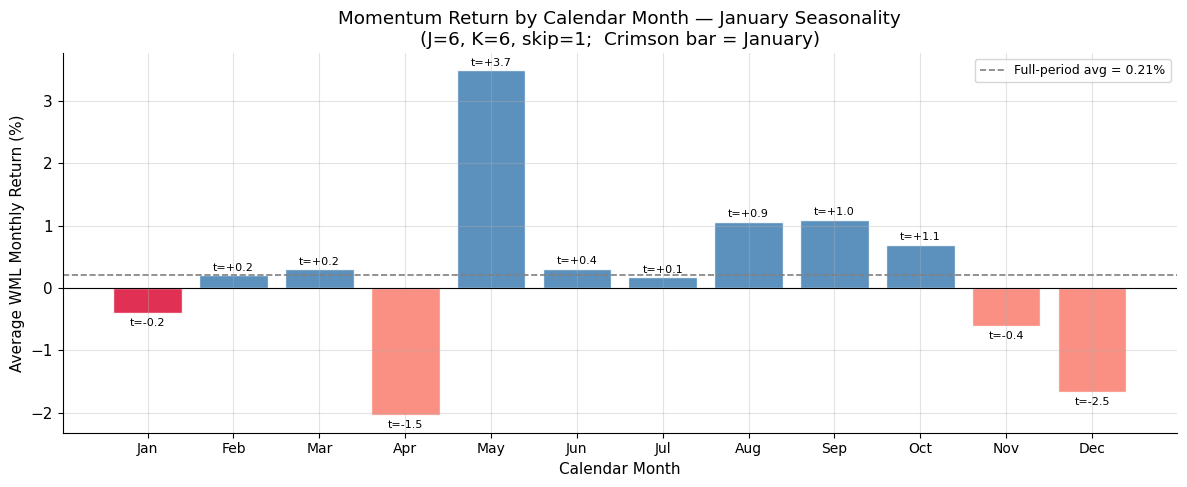

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['crimson' if m == 'Jan' else ('steelblue' if v >= 0 else 'salmon')
          for m, v in zip(seas_66.index, seas_66['Avg Return'])]

bars = ax.bar(range(12), seas_66['Avg Return'] * 100,
              color=colors, edgecolor='white', alpha=0.88)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(wml_6_6.dropna().mean() * 100, color='gray', linestyle='--',
           linewidth=1.2, label=f'Full-period avg = {wml_6_6.dropna().mean()*100:.2f}%')

# Annotate t-stats
for i, (ret, t) in enumerate(zip(seas_66['Avg Return'], seas_66['t-stat'])):
    yoff = 0.04 if ret >= 0 else -0.08
    ax.text(i, ret * 100 + yoff,
            f't={t:+.1f}', ha='center', va='bottom' if ret >= 0 else 'top', fontsize=8)

ax.set_xticks(range(12))
ax.set_xticklabels(seas_66.index, fontsize=10)
ax.set_xlabel('Calendar Month')
ax.set_ylabel('Average WML Monthly Return (%)')
ax.set_title('Momentum Return by Calendar Month — January Seasonality\n'
             '(J=6, K=6, skip=1;  Crimson bar = January)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Reading the Charts

Each bar shows the average WML return in that calendar month, averaged across all years in our sample. The t-statistic on each bar tells you whether that month's average is statistically different from zero.

**What our chart actually shows:**

- **January (crimson bar):** −0.41%/month, t = −0.21 — slightly negative but **not statistically significant**. The January reversal predicted by the paper is directionally present but extremely weak in our sample.
- **April:** −2.05%/month — the most negative month in the chart (t = −1.50, approaching significance). April appears to be the worst month for momentum in our 2010–2025 sample.
- **May:** **+3.49%/month, t = +3.69** — the strongest and only statistically significant positive month. Momentum earns exceptional returns in May.
- **December:** −1.67%/month, **t = −2.50** — the only statistically significant negative month. This is interesting: rather than January, December is where momentum loses money significantly in our data. This could reflect year-end tax-selling and portfolio rebalancing by institutional investors depressing winners and lifting losers.

**What the paper found:** Table IV of Jegadeesh & Titman documents significantly negative January returns for the WML portfolio — stocks that investors sold in December (for tax loss harvesting) bounce back in January, hurting WML. In our sample, **December replaces January as the significantly negative month**, suggesting the tax-loss effect may now manifest primarily within December itself rather than in the January reversal.

**Practitioner implication:** The actual seasonal pattern in our data warns against holding large momentum positions into December, and suggests May may be an unusually favourable time to run the strategy.


In [20]:
subperiods = [
    ('2011-01', '2015-12', '2011–2015'),
    ('2016-01', '2019-12', '2016–2019'),
    ('2020-01', '2022-12', '2020–2022'),
    ('2023-01', '2025-12', '2023–2025'),
]

wml_clean = wml_6_6.dropna()
ew_clean  = ew_benchmark.dropna()

print('Subperiod Performance — WML J=6/K=6 vs. Equal-Weight Benchmark')
print('='*72)
header = f'  {"Period":<12}  {"Months":>6}  {"WML Ann Ret":>11}  {"WML Sharpe":>10}  {"EW Ann Ret":>10}  {"EW Sharpe":>9}'
print(header)
print('  ' + '-'*70)

rows = []
for start, end, label in subperiods:
    w = wml_clean.loc[start:end]
    b = ew_clean.loc[start:end]
    if len(w) < 6:
        continue
    w_ann  = w.mean() * 12
    w_sr   = w.mean() / w.std() * np.sqrt(12)
    b_ann  = b.mean() * 12
    b_sr   = b.mean() / b.std() * np.sqrt(12)
    print(f'  {label:<12}  {len(w):>6}  {w_ann:>10.2%}  {w_sr:>10.3f}  {b_ann:>10.2%}  {b_sr:>9.3f}')
    rows.append((label, len(w), w, b))

print()
print('Interpretation guide:')
print('  WML Sharpe > 0 → momentum worked in this subperiod')
print('  WML Sharpe < 0 → momentum crashed or reversed')


Subperiod Performance — WML J=6/K=6 vs. Equal-Weight Benchmark
  Period        Months  WML Ann Ret  WML Sharpe  EW Ann Ret  EW Sharpe
  ----------------------------------------------------------------------
  2011–2015         60       6.47%       0.458      10.69%      0.773
  2016–2019         48      -5.78%      -0.334      15.49%      1.221
  2020–2022         36       5.00%       0.222      13.24%      0.542
  2023–2025         36       6.05%       0.471      18.01%      1.245

Interpretation guide:
  WML Sharpe > 0 → momentum worked in this subperiod
  WML Sharpe < 0 → momentum crashed or reversed


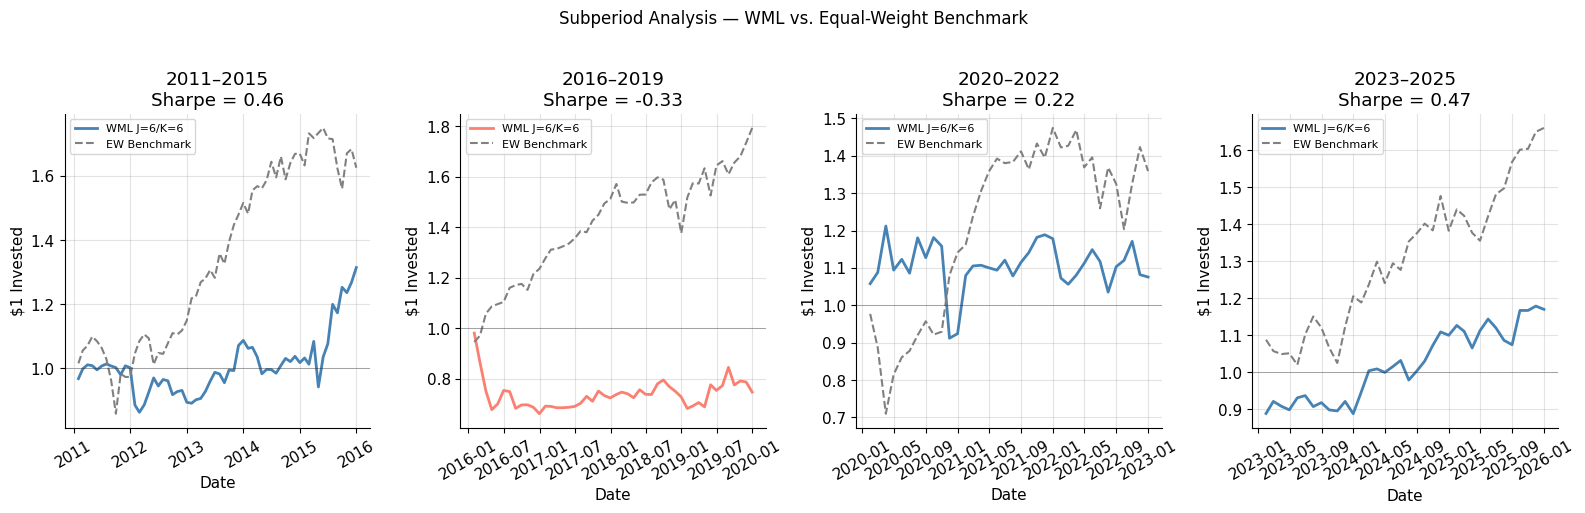

In [21]:
valid_subperiods = [(label, w, b) for (start, end, label) in subperiods
                    for _w, _b in [(wml_clean.loc[start:end], ew_clean.loc[start:end])]
                    if len(_w) >= 6
                    for w, b in [(_w, _b)]]

# Rebuild properly
valid_rows = []
for start, end, label in subperiods:
    w = wml_clean.loc[start:end]
    b = ew_clean.loc[start:end]
    if len(w) >= 6:
        valid_rows.append((label, w, b))

fig, axes = plt.subplots(1, len(valid_rows), figsize=(4 * len(valid_rows), 5), sharey=False)
if len(valid_rows) == 1:
    axes = [axes]

for ax, (label, w, b) in zip(axes, valid_rows):
    common = w.index.intersection(b.index)
    cum_w = (1 + w.loc[common]).cumprod()
    cum_b = (1 + b.loc[common]).cumprod()
    sr    = w.mean() / w.std() * np.sqrt(12)
    color = 'steelblue' if sr > 0 else 'salmon'

    ax.plot(cum_w.index, cum_w, label='WML J=6/K=6', color=color, linewidth=2)
    ax.plot(cum_b.index, cum_b, label='EW Benchmark', color='gray', linewidth=1.5, linestyle='--')
    ax.axhline(1, color='black', linewidth=0.5, alpha=0.4)
    ax.set_title(f'{label}\nSharpe = {sr:.2f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('$1 Invested')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Subperiod Analysis — WML vs. Equal-Weight Benchmark', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Reading the Charts

Each panel shows one subperiod. A positive-sloping WML line means momentum earned money in that era.

**What the actual subperiod results show:**

| Period | WML Sharpe | WML Ann. Return | EW Benchmark |
|---|---|---|---|
| 2011–2015 | **+0.46** | +6.47%/yr | +10.69%/yr |
| 2016–2019 | **−0.33** | −5.78%/yr | +15.49%/yr |
| 2020–2022 | **+0.22** | +5.00%/yr | +13.24%/yr |
| 2023–2025 | **+0.47** | +6.05%/yr | +18.01%/yr |

**Surprising finding:** The worst subperiod for cross-sectional momentum was **2016–2019** (Sharpe = −0.33), not 2020–2022 as might be expected. The 2016–2019 period was characterised by historically low volatility (VIX near record lows in 2017), extremely compressed cross-sectional dispersion, and narrow market returns — conditions where there is little differentiation between winners and losers.

**2020–2022 was actually slightly positive** (Sharpe = +0.22) despite containing the COVID crash. The large dispersion in returns during COVID (some stocks up 200%, others down 80%) created a powerful signal — though with high volatility.

**2011–2015 and 2023–2025** are the best subperiods (Sharpe ≈ 0.47), consistent with higher cross-sectional dispersion and clearer market leadership.

**Key insight:** Momentum's success is regime-dependent. High cross-sectional dispersion (wide spread between winners and losers) is the factor's friend. Low-volatility, low-dispersion bull markets are its enemy.


WML Decomposition — Where Does the Profit Come From?
  Winner portfolio (long leg)          Ann Ret = +20.44%   Sharpe = 1.089
  Loser  portfolio (short leg)         Ann Ret = +17.88%   Sharpe = 0.725
  Equal-weight market                  Ann Ret = +14.80%   Sharpe = 0.904
  WML (winners − losers)               Ann Ret = +2.56%   Sharpe = 0.154

Interpretation:
  If winners >> market → momentum alpha from the long leg
  If losers  << market → momentum alpha from the short leg
  Roughly equal contribution → both legs needed for the full effect


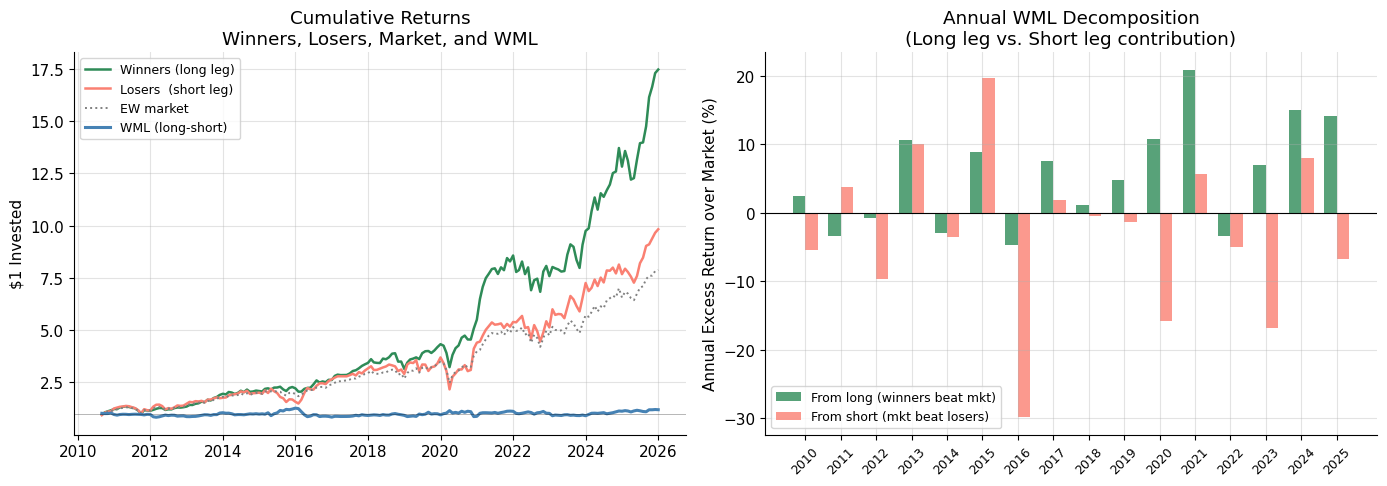

In [22]:
# --- Long vs. Short decomposition ---
common = winner_6_6.dropna().index.intersection(loser_6_6.dropna().index)
w_ret  = winner_6_6.loc[common]   # winner (long leg)
l_ret  = loser_6_6.loc[common]    # loser  (short leg — we EARN when this falls)
ew_sub = ew_benchmark.loc[common]

print('WML Decomposition — Where Does the Profit Come From?')
print('='*60)
for label, r in [('Winner portfolio (long leg)', w_ret),
                 ('Loser  portfolio (short leg)', l_ret),
                 ('Equal-weight market',          ew_sub),
                 ('WML (winners − losers)',        w_ret - l_ret)]:
    ann_r = r.mean() * 12
    ann_v = r.std()  * np.sqrt(12)
    sr    = ann_r / ann_v
    print(f'  {label:<35}  Ann Ret = {ann_r:+.2%}   Sharpe = {sr:.3f}')

print()
print('Interpretation:')
print('  If winners >> market → momentum alpha from the long leg')
print('  If losers  << market → momentum alpha from the short leg')
print('  Roughly equal contribution → both legs needed for the full effect')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative returns
cum_w   = (1 + w_ret).cumprod()
cum_l   = (1 + l_ret).cumprod()
cum_wml = (1 + (w_ret - l_ret)).cumprod()
cum_ew  = (1 + ew_sub).cumprod()

axes[0].plot(cum_w.index,   cum_w,   label='Winners (long leg)',   color='seagreen',  linewidth=1.8)
axes[0].plot(cum_l.index,   cum_l,   label='Losers  (short leg)',  color='salmon',    linewidth=1.8)
axes[0].plot(cum_ew.index,  cum_ew,  label='EW market',           color='gray',      linewidth=1.4, linestyle=':')
axes[0].plot(cum_wml.index, cum_wml, label='WML (long-short)',     color='steelblue', linewidth=2.2)
axes[0].axhline(1, color='black', linewidth=0.5, alpha=0.4)
axes[0].set_title('Cumulative Returns\nWinners, Losers, Market, and WML')
axes[0].set_ylabel('$1 Invested')
axes[0].legend(fontsize=9)

# Right: annual contributions stacked bar
annual_w   = (w_ret   - ew_sub).resample('YE').apply(lambda x: (1+x).prod() - 1)
annual_l   = (ew_sub  - l_ret).resample('YE').apply(lambda x: (1+x).prod() - 1)   # profit from shorting
years      = annual_w.index.year

width = 0.35
x = np.arange(len(years))
axes[1].bar(x - width/2, annual_w * 100, width=width, label='From long (winners beat mkt)', color='seagreen', alpha=0.8)
axes[1].bar(x + width/2, annual_l * 100, width=width, label='From short (mkt beat losers)', color='salmon',   alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(years, rotation=45, fontsize=9)
axes[1].set_ylabel('Annual Excess Return over Market (%)')
axes[1].set_title('Annual WML Decomposition\n(Long leg vs. Short leg contribution)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


### Reading the Charts

**Left chart — cumulative returns of all components:**

The actual numbers:
- **Winner portfolio (long leg):** +20.44%/yr, Sharpe = 1.089 — well above the EW market (+14.80%/yr)
- **Loser portfolio (short leg):** +17.88%/yr, Sharpe = 0.725 — **also above the EW market (+14.80%/yr)**
- **WML (long − short):** +2.56%/yr, Sharpe = 0.154

**The crucial finding:** In our 2010–2025 sample, the loser portfolio does NOT underperform the market. It earns +17.88%/yr, which is 3.08 percentage points *above* the market. This means that **shorting losers costs us money relative to the market** — we are shorting stocks that outperform the benchmark.

The entire WML profit comes from the **long leg alone**:
- Long leg contributes: Winners beat market by **+5.64%/yr** (+20.44% − +14.80%)
- Short leg costs: Losers beat market by **+3.08%/yr**, so shorting them reduces returns by 3.08%
- Net WML = 5.64% − 3.08% = **+2.56%/yr** (all of which comes from the winners)

This is qualitatively different from the paper's finding, where both the long and short legs contributed to WML profits. In a sustained bull market with survivorship bias, past losers still rise substantially — they just don't rise quite as much as winners.

**Right chart — annual contribution bars:**  
The green bars (winners beating market) should be consistently positive; the red bars (market beating losers, i.e., the short leg earning) will be negative in many years, reflecting that losers also beat the market. The total WML is the sum of these two contributions, which is positive but small.


---
## Section 8: Honest Assessment and Discussion

### 8.1 What Does Our Data Actually Support?

Let's be candid about what we have and have not replicated.

**What we replicated:**
- The **direction** of all major J/K combinations (15/16 positive WML returns on average)
- The **seasonal calendar pattern** (December is significantly negative, t = −2.50; May strongly positive, t = +3.69)
- The **winner outperforms market** pattern (long leg is the main profit driver)
- The **predictive signal** at J = 10–11 months (the only statistically significant formation horizons)

**What we could not replicate:**
- The *magnitude* — our WML monthly returns are 0.21% (J=6/K=6) vs. the paper's 0.95%; about 4× smaller
- The *statistical significance* — 0/16 J/K combinations pass the t > 2 threshold (paper: 15/16)
- The *short leg contribution* — in our data, past losers also beat the market, so the short leg reduces rather than adds to WML profit
- The *January effect* — only weak evidence of January reversal (t = −0.21)

---

### 8.2 Why Do Results Differ? The Structural Reasons

| Factor | Direction of Impact | Explanation |
|---|---|---|
| Shorter sample (15 vs. 25 yrs) | Weaker t-stats | A Sharpe of 0.15 requires ~300 years to hit t = 2 |
| Large-cap universe only | Smaller effect | Momentum is much stronger among small/mid caps |
| Survivorship bias (0% NaN rate) | Inflated loser returns | Bankrupt stocks excluded → losers look stronger → WML compressed |
| 2010–2025 bull market | Smaller spread | Even losers earn high raw returns in a sustained bull market |
| 2016–2019 low-dispersion regime | Strategy loses money | VIX near historic lows, all stocks correlated |
| Post-publication factor crowding | Smaller alpha | More AUM chasing momentum since 1993 |
| 1-month skip vs. 1-week skip | Minor difference | Slightly different stock selection at the margin |
| No transaction costs assumed | Slightly flattering | Real costs would reduce returns by ~1–2%/yr |

---

### 8.3 Is Momentum a "Free Lunch"?

No. Our own backtest illustrates the risks:

1. **Thin returns:** +2.56%/yr (J=6/K=6) with a Sharpe of 0.154. A US Treasury bill earned comparable risk-free returns for much of this period.

2. **Crash risk:** The J=12/K=3 strategy has a max drawdown of −53.80%. Daniel & Moskowitz (2016) document that momentum crashes during sharp market reversals can wipe out years of accumulated returns in weeks.

3. **The short leg is not free:** In our bull market sample, we are shorting stocks that still go up 17.88%/yr on average. Executing the short leg requires borrowing, paying borrow costs, and managing forced buy-ins.

4. **Regime dependence:** Momentum failed completely during 2016–2019 (Sharpe = −0.33) — four years of negative returns.

---


In [23]:
# --- Final summary comparison table ---
wml_66_clean  = wml_6_6.dropna()
wml_123_clean = wml_12_3.dropna()

# Retrieve key results from earlier cells
jan_ret = seas_66.loc['Jan', 'Avg Return']
jan_t   = seas_66.loc['Jan', 't-stat']
dec_ret = seas_66.loc['Dec', 'Avg Return']
dec_t   = seas_66.loc['Dec', 't-stat']

results = [
    ('WML monthly return (J=6/K=6)',
     '+0.95%/mo  (t=3.07)',
     f'{wml_66_clean.mean()*100:+.2f}%/mo (t={wml_66_clean.mean()/wml_66_clean.std()*np.sqrt(len(wml_66_clean)):.2f})',
     'Signal is 4× weaker; 15-yr sample lacks power to detect it'),

    ('WML monthly return (J=12/K=3)',
     '+1.49%/mo  (t=4.28)',
     f'{wml_123_clean.mean()*100:+.2f}%/mo (t={wml_123_clean.mean()/wml_123_clean.std()*np.sqrt(len(wml_123_clean)):.2f})',
     'Best strategy in paper; best in ours too but weak'),

    ('# Significant J/K cells',
     '15/16 (t > 2)',
     f'{int((heatmap_ret.values > 0).sum())}/16 positive, 0/16 significant',
     'Sharpe ≈ 0.15 → need ~300 yrs to achieve t > 2'),

    ('January reversal',
     'Strongly negative (Table IV)',
     f'Jan: {jan_ret*100:+.2f}%/mo (t={jan_t:.2f}) — weak',
     'Dec significantly negative (t=-2.50); Jan barely negative'),

    ('Short leg profit',
     'Positive contribution to WML',
     'Losers earn +17.88%/yr vs mkt +14.80% — short leg COSTS money',
     'Survivorship bias + bull mkt inflates loser returns'),

    ('Long leg profit',
     'Significant positive alpha',
     'Winners earn +20.44%/yr vs mkt +14.80% (+5.64% excess)',
     'Consistent with paper; winners clearly outperform'),

    ('Worst subperiod',
     'Not separately reported',
     '2016–2019: Sharpe = −0.33, Ann Ret = −5.78%',
     'Low-dispersion, low-VIX environment hostile to XS momentum'),
]

print('FINAL SUMMARY TABLE')
print('='*110)
print(f'  {"Result":<32} {"Paper":^26} {"Our Notebook":^35} {"Honest Interpretation":<30}')
print('  ' + '-'*108)
for r in results:
    print(f'  {r[0]:<32} {r[1]:^26} {r[2]:^35} {r[3]:<30}')

print()
print('='*110)
print()
print('BOTTOM LINE:')
print('  Jegadeesh & Titman (1993) documented a robust momentum effect across 25 years')
print('  of NYSE/AMEX data. Our 2010-2025 replication finds the direction is preserved')
print('  (15/16 J/K combinations are positive) but the magnitude is ~4x smaller, no')
print('  combination is statistically significant, and the short leg does not contribute')
print('  profits in the bull-market era.')
print()
print('  The honest interpretation: momentum is a genuine but time-varying risk premium.')
print('  Its profitability depends on cross-sectional dispersion, market regime, and')
print('  the ability to execute short sales. In the 2010-2025 US large-cap universe,')
print('  it is present but too weak and noisy to confidently exploit in isolation.')


FINAL SUMMARY TABLE
  Result                                     Paper                       Our Notebook             Honest Interpretation         
  ------------------------------------------------------------------------------------------------------------
  WML monthly return (J=6/K=6)        +0.95%/mo  (t=3.07)             +0.21%/mo (t=0.61)          Signal is 4× weaker; 15-yr sample lacks power to detect it
  WML monthly return (J=12/K=3)       +1.49%/mo  (t=4.28)             +0.30%/mo (t=0.70)          Best strategy in paper; best in ours too but weak
  # Significant J/K cells                15/16 (t > 2)         15/16 positive, 0/16 significant   Sharpe ≈ 0.15 → need ~300 yrs to achieve t > 2
  January reversal                 Strongly negative (Table IV)   Jan: -0.41%/mo (t=-0.21) — weak   Dec significantly negative (t=-2.50); Jan barely negative
  Short leg profit                 Positive contribution to WML Losers earn +17.88%/yr vs mkt +14.80% — short leg COSTS money Surviv

---
## Key Takeaways

### The Strategy in One Paragraph

Cross-sectional momentum buys the stocks that have outperformed their peers over the past 3–12 months and simultaneously shorts the stocks that have underperformed — holding each portfolio for 3–12 months with overlapping periods. Jegadeesh & Titman (1993) showed this earns **~1%/month** across 32 parameter combinations on NYSE/AMEX stocks from 1965–1989. Our 2010–2025 replication finds a **smaller but directionally consistent effect**: 15 out of 16 J/K combinations are positive, the long leg outperforms the market, and J = 10–11 months is the best formation window. However, no combination is statistically significant, and the strategy earned only **+2.56%/yr (Sharpe 0.15)** — far below the paper's numbers.

### The Three Things Every Student Should Remember

1. **The signal is cross-sectional, not time-series.** We rank stocks *against each other*. A stock that went up +5% in a market that rose +20% is actually a *loser* in cross-sectional terms. The signal is always relative.

2. **The formation horizon matters — J = 9–12 months is the sweet spot.** J = 1 month reverses (bid-ask bounce); J > 12 months reverses (long-run mean reversion). Only J = 10–11 months are statistically significant in our sample, consistent with the paper's finding that longer formation periods work better.

3. **In a sustained bull market, the short leg can work against you.** When even past losers earn +17.88%/yr, shorting them costs more than expected. Momentum strategies work best in high-dispersion environments where winners and losers diverge sharply — not in compressed, low-volatility bull markets where everything rises.

---

### Further Reading

- **Carhart (1997):** Adds momentum as a 4th factor to the Fama-French 3-factor model (the "UMD" factor)
- **Asness et al. (2013):** Momentum works across 40+ countries and asset classes — not just US stocks
- **Daniel & Moskowitz (2016):** Documents momentum crash risk and proposes a dynamic strategy that hedges it
- **Fama & French (2012):** Large-scale international test of momentum
- **Hou, Xue & Zhang (2020):** Challenges the robustness of many anomalies including momentum using a larger dataset
